In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical parameters ( Table 1) ---
Lx , Ly = 600 *1e3 , 240* 1e3 # domain size [ m ]
Nx , Ny = 256 , 102 # grid resolution
g_prime = 0.3 # reduced gravity [ m / s ^2]
H0 = 1000.0 # mean layer depth [ m ]
U0 = 8.0 # inflow wind speed [ m / s ]
R0 = 20 *1e3 # island radius [ m ]
Cd = 0.02 # drag coefficient [1/ s ]
nu = 1000.0 # eddy viscosity [ m ^2/ s ]
dt = 30.0 # time step [ s ]
# --- Grid : x has walls ( keep endpoints ) , y is periodic ( drop last point ) ---
x = np . linspace (0 , Lx , Nx )
y = np . linspace (0 , Ly , Ny , endpoint = False )
dx = x [1] - x [0]
dy = y [1] - y [0]
X , Y = np . meshgrid (x , y ) # shape ( Ny , Nx ) : x along columns , y along rows
# --- Initial fields ---
rng = np.random.default_rng(0)
h = np.full (( Ny , Nx ) , H0 )
u = np.full (( Ny , Nx ) , U0 ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
v = np.zeros (( Ny , Nx ) ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
# --- Gaussian mountain mask C (x , y ) , centred at ( Lx /3 , Ly /2) ---
xc , yc = Lx /3 , Ly /2
C = np.exp ( -((( X - xc ) **2 + ( Y - yc ) **2) / (0.35* R0 ) **2) )


In [2]:
def ddx ( q ) :
    out = np . zeros_like ( q )
    out [: , 1: -1] = ( q [: , 2:] - q [: , : -2]) / (2* dx ) # central , O (dx ^2)
    out [: , 0] = ( q [: , 1] - q [: , 0]) / dx # forward at x = 0
    out [: , -1] = ( q [: , -1] - q [: , -2]) / dx # backward at x = Lx
    return out
def ddy ( q ) :
# y is periodic -> centred difference with np . roll along the rows
    return ( np . roll (q , -1 , axis =0) - np . roll (q , 1 , axis =0) ) / (2* dy )
def laplacian ( q ) :
    d2x = np . zeros_like ( q )
    d2x [: , 1: -1] = ( q [: , 2:] - 2* q [: , 1: -1] + q [: , : -2]) / dx **2
    d2x [: , 0] = ( q [: , 0] - 2* q [: , 1] + q [: , 2]) / dx **2 # one - sided wall
    d2x [: , -1] = ( q [: , -1] - 2* q [: , -2] + q [: , -3]) / dx **2 # one - sided wall
    d2y = ( np . roll (q , -1 , axis =0) - 2* q + np . roll (q , 1 , axis =0) ) /dy **2
    return d2x + d2y

In [3]:
q = np . sin (2* np . pi * X / Lx )
num = ddx ( q )
ana = (2* np . pi / Lx ) * np . cos (2* np . pi * X / Lx )
print ( " max relative error : " , np . abs ( num - ana ) . max () / (2* np . pi / Lx ) )

 max relative error :  0.00010118472178036849


In [4]:
def rhs(h,u,v):
    
    dh_dt = -ddx(h*u) - ddy(h*v)

    du_dt = (-u * ddx(u)
               - v * ddy(u)
               - g_prime * ddx(h)
               + nu * laplacian(u)
               - Cd * C * u)
    
    dv_dt = (-u * ddx(v)
               - v * ddy(v)
               - g_prime * ddy(h)
               + nu * laplacian(v)
               - Cd * C * v)
    
    return dh_dt, du_dt, dv_dt

    

In [5]:
def rk2_step(h, u, v):
      
      dh1, du1, dv1 = rhs(h, u, v)

      h1 = h + dt * dh1
      u1 = u + dt * du1
      v1 = v + dt * dv1

      
      dh2, du2, dv2 = rhs(h1, u1, v1)
      h2 = h + dt/2 * (dh1 + dh2)
      u2 = u + dt/2 * (du1 + du2)
      v2 = v + dt/2 * (dv1 + dv2)

      return h2, u2, v2


def boundary_conditions(h, u, v):
      #west
      u[:, 0] = U0
      v[:, 0] = 00
      h[:, 0] = H0

      #east
      u[:, -1] = u[:, -2]
      v[:, -1] = v[:, -2]
      h[:, -1] = h[:, -2]

      return h, u ,v
    

In [6]:
def update_rk2(h,u,v, steps = 60000):
    for n in range(steps):
        h, u, v = rk2_step(h,u,v)
        h, u, v = boundary_conditions(h,u,v)

        if n % 500 == 0:
              zeta = ddx(v) - ddy(u)
              print(n)
              plt.figure(figsize=(12, 4))
              plt.contourf(X/1e3, Y/1e3, zeta, levels=50, cmap='seismic') #RdBu_r
              plt.colorbar(label='vorticity [1/s]')
              plt.title(f"iteration number = {n/500}")
              plt.xlabel('x [km]')
              plt.ylabel('y [km]')
              plt.tight_layout()
              plt.show()

        
    return h, u, v


0


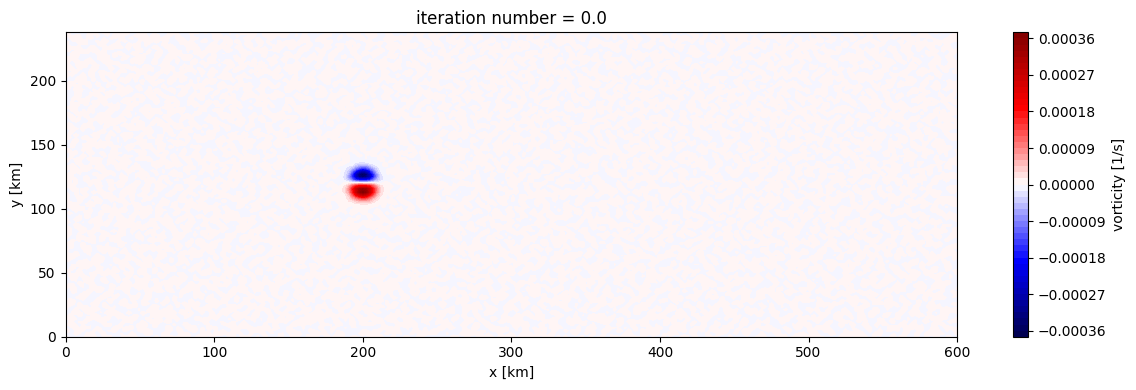

500


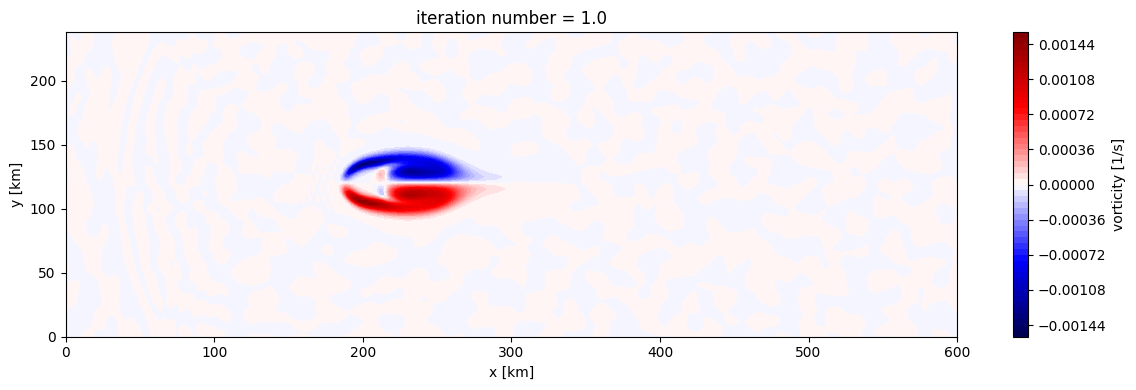

1000


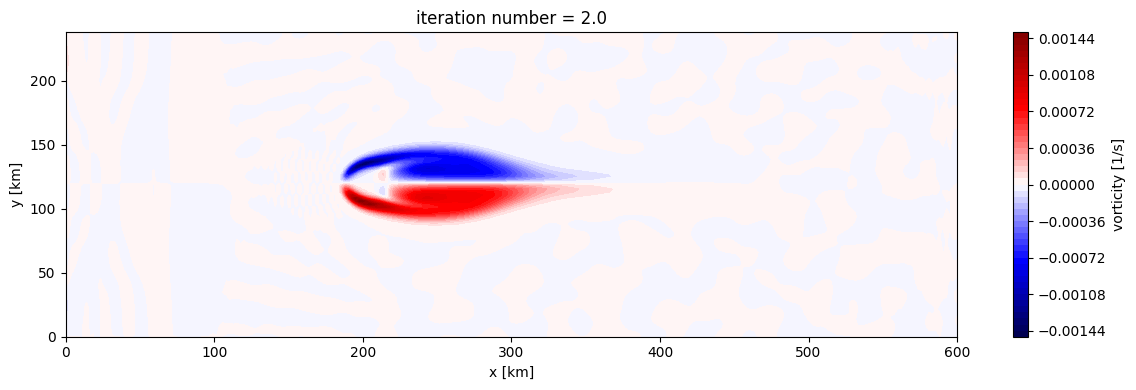

1500


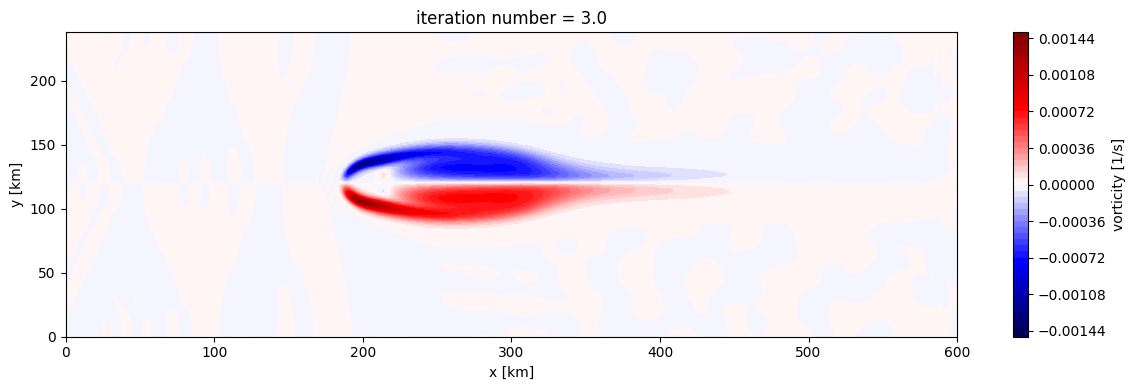

2000


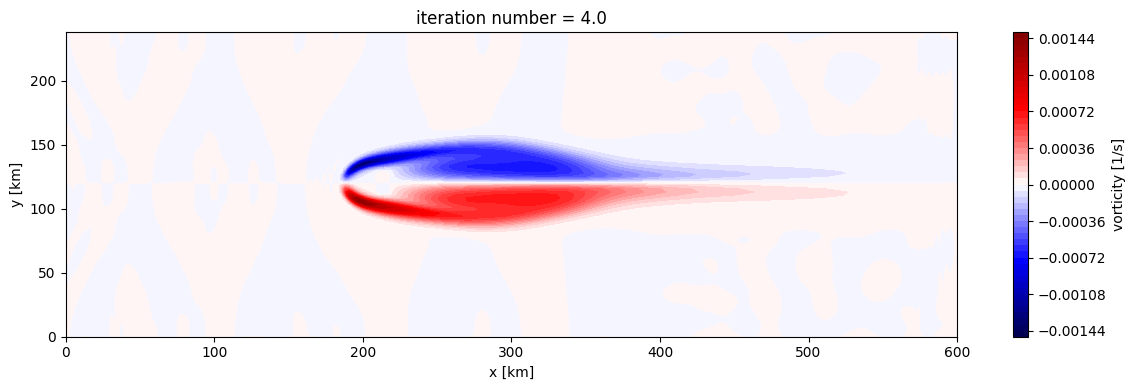

2500


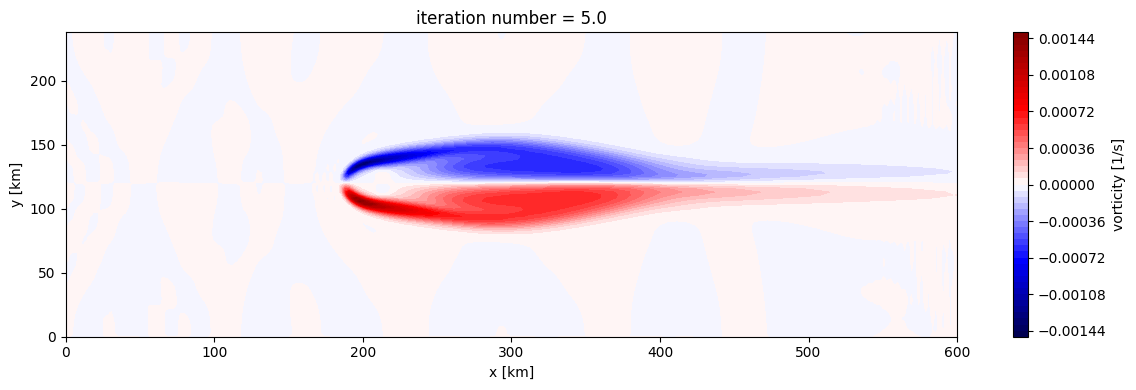

3000


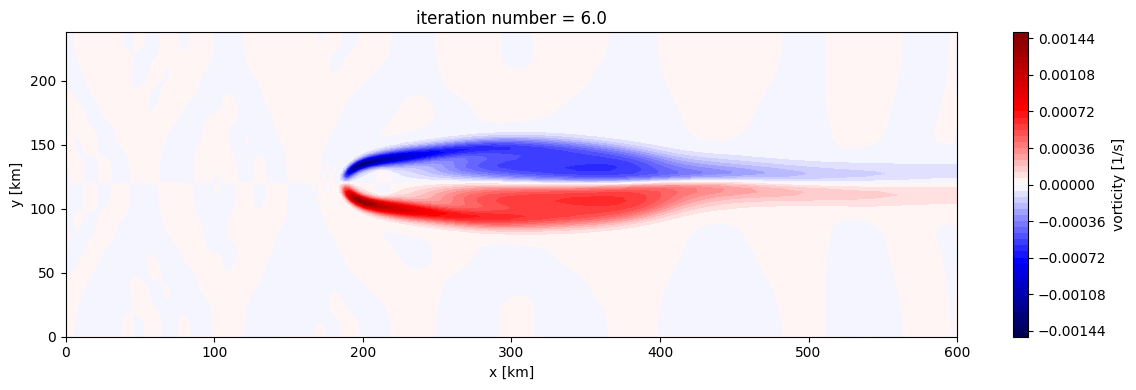

3500


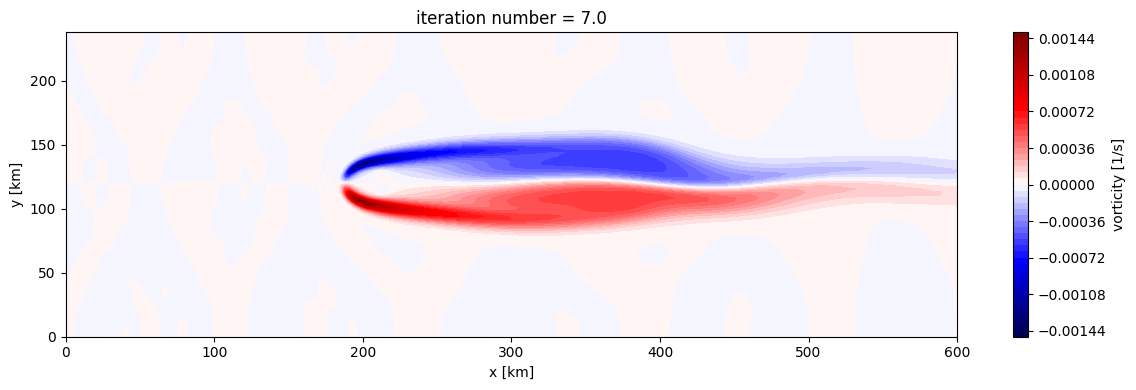

4000


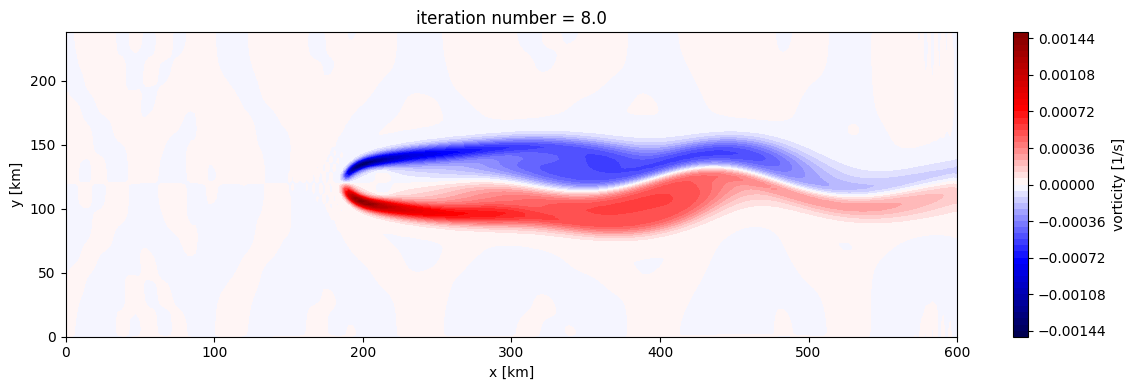

4500


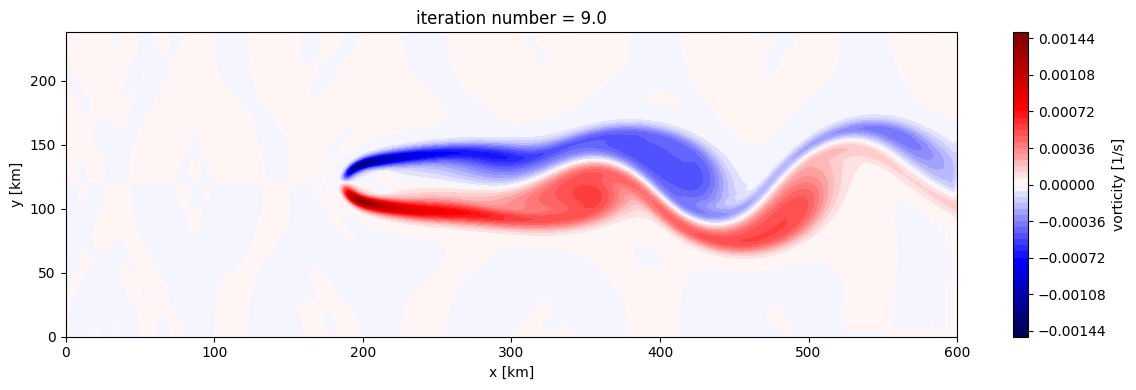

5000


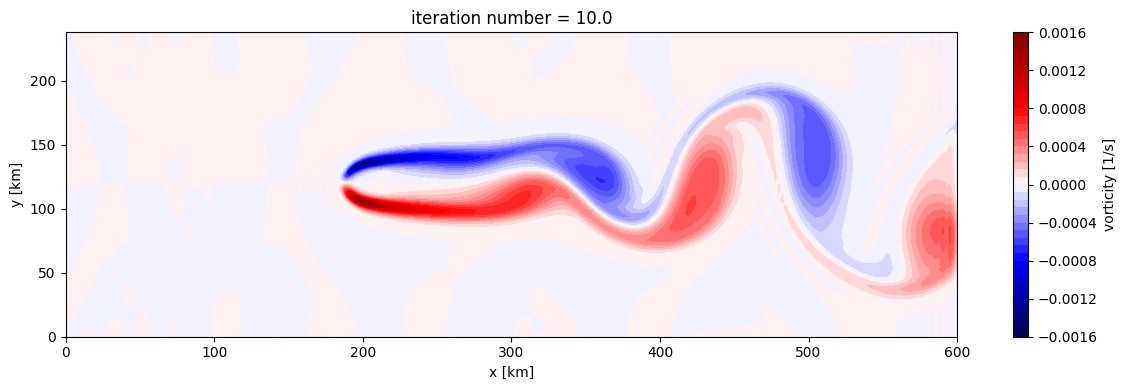

5500


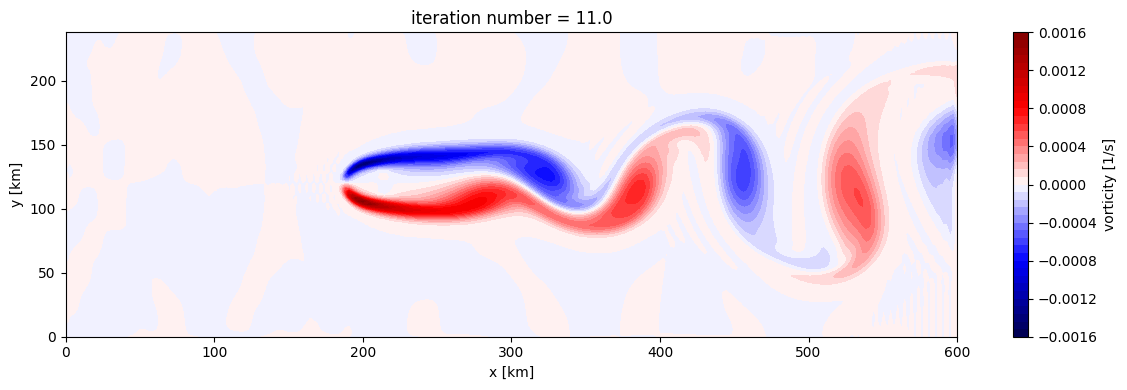

6000


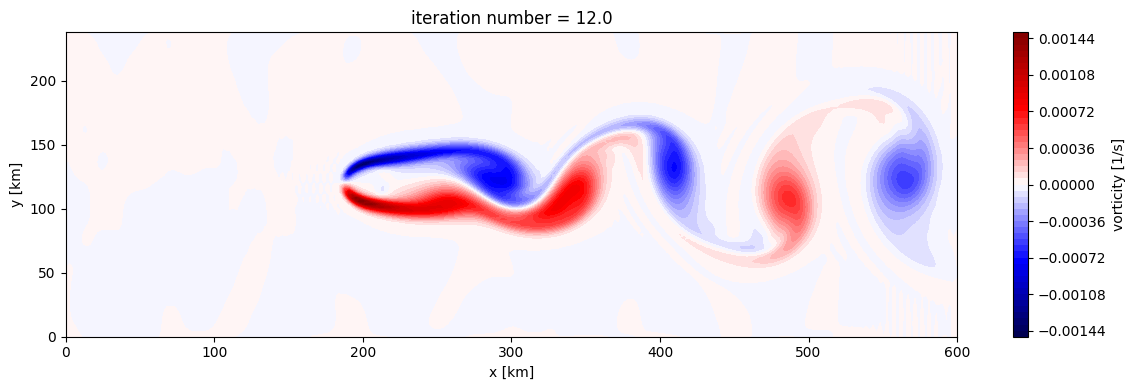

6500


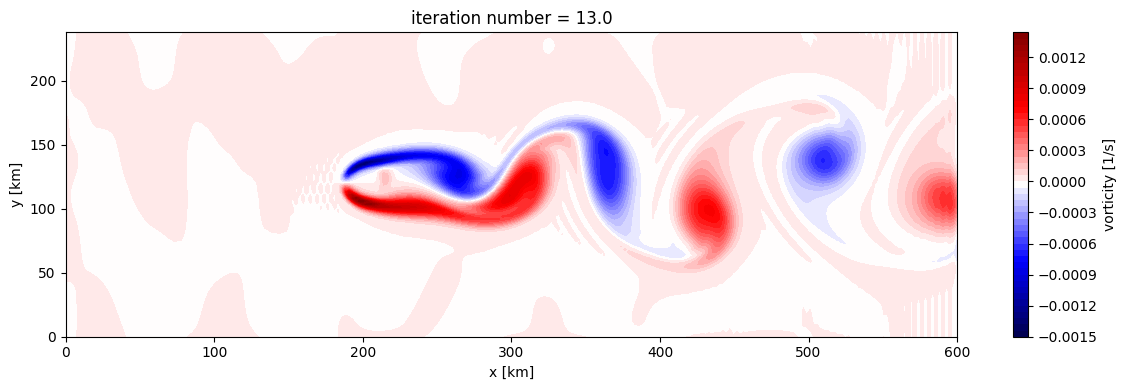

7000


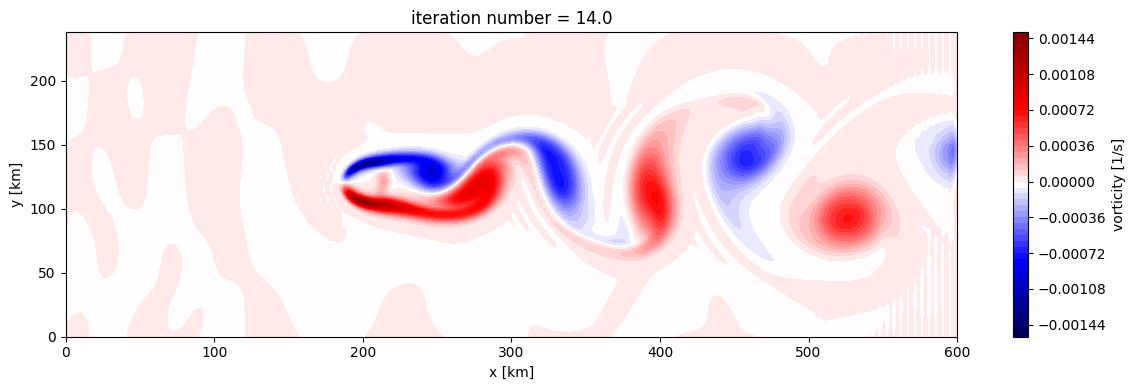

7500


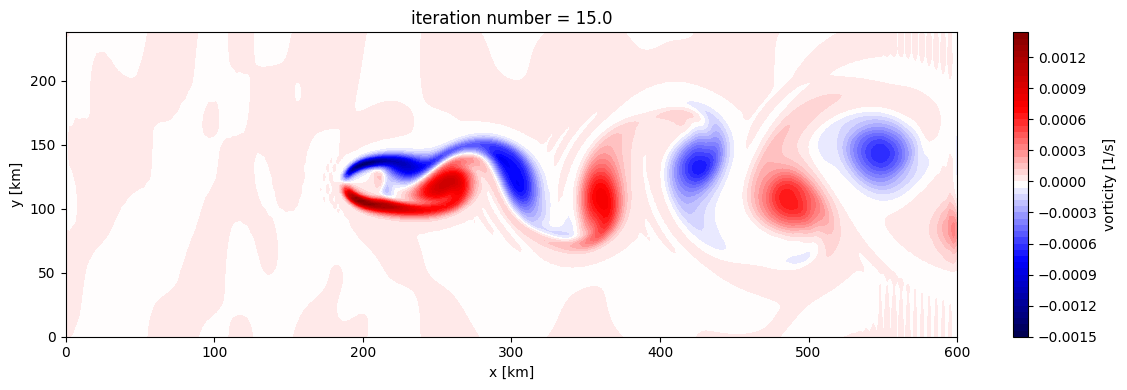

8000


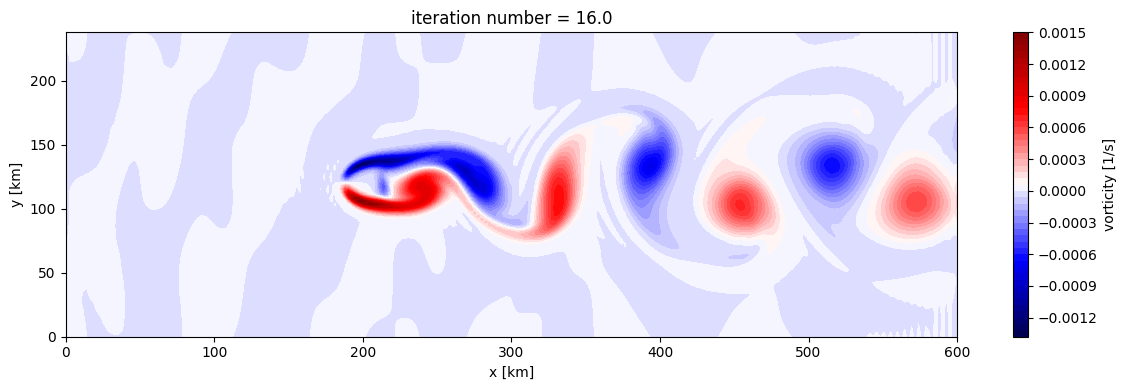

8500


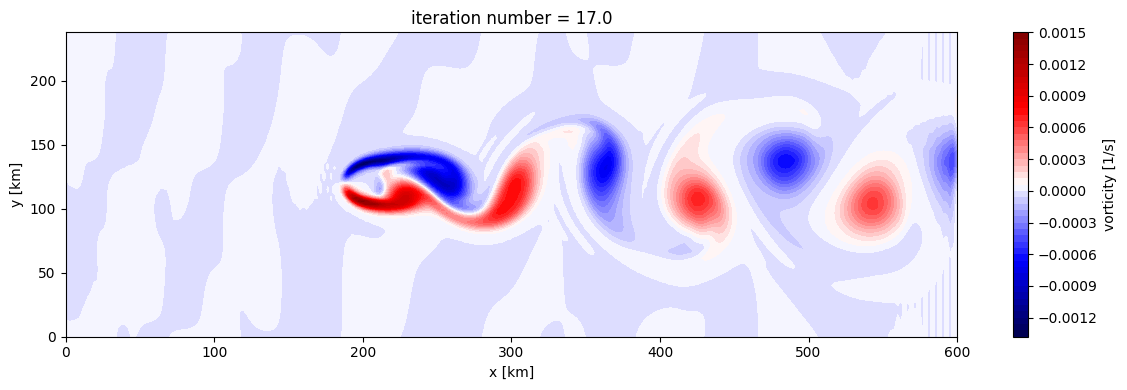

9000


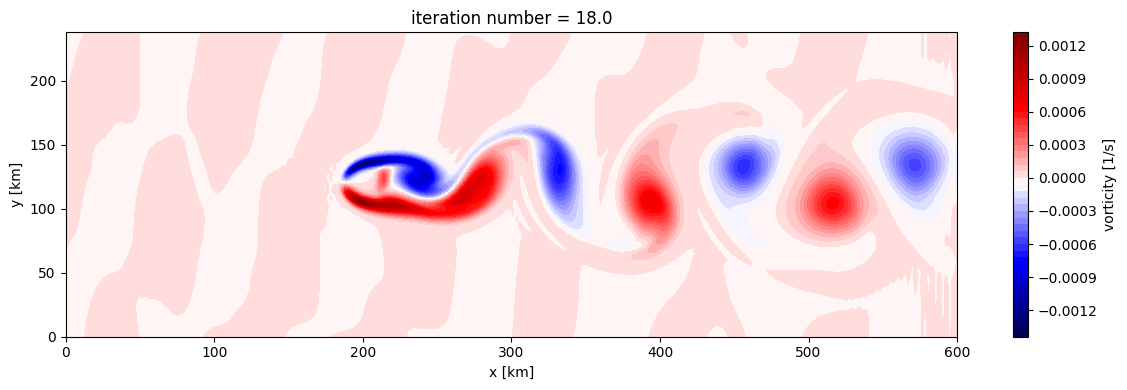

9500


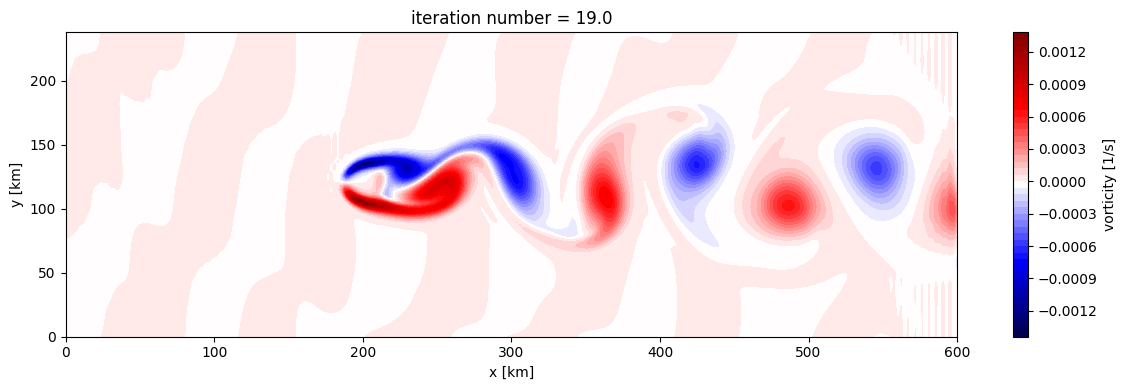

10000


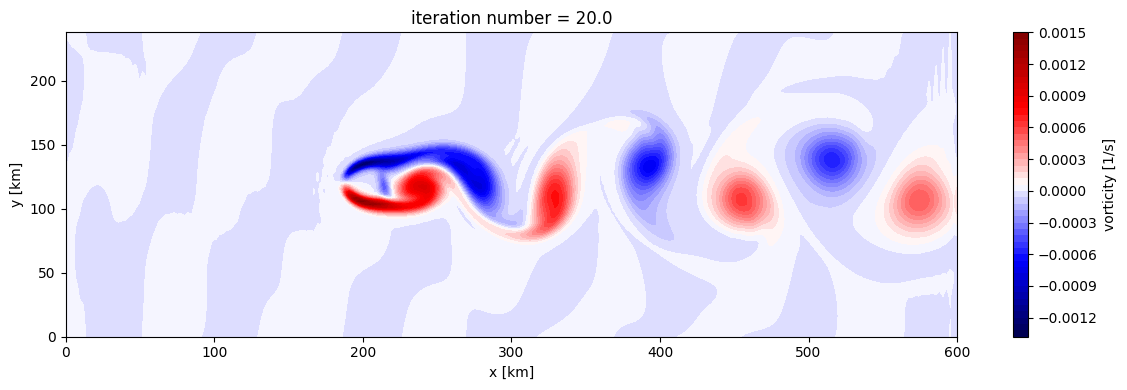

10500


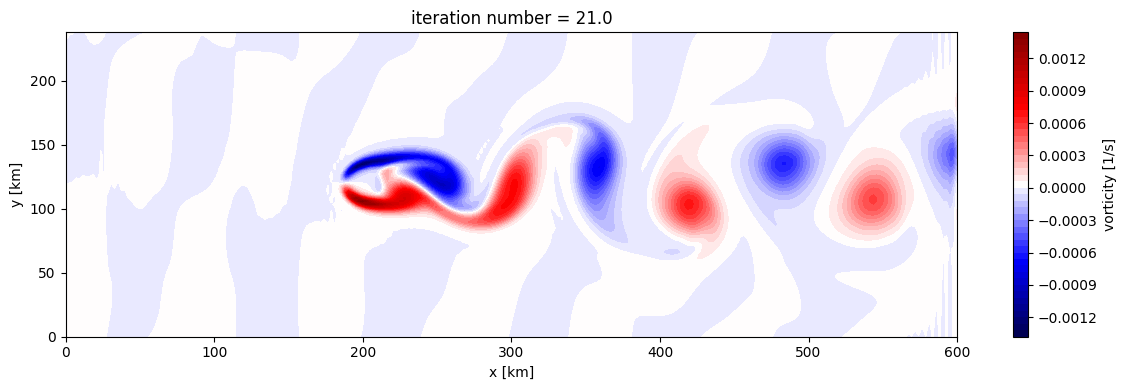

11000


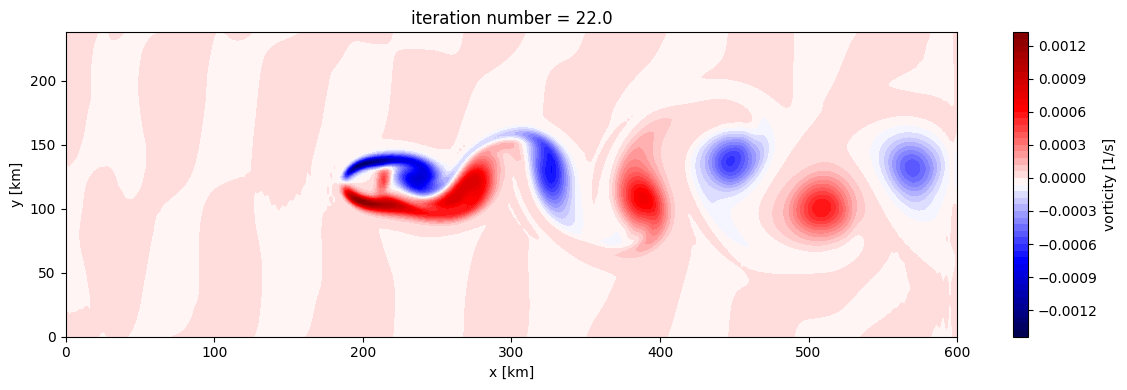

11500


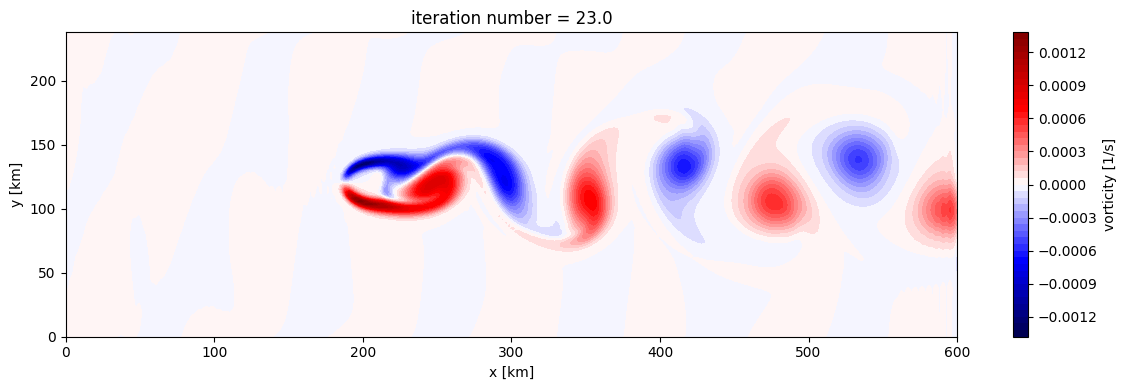

12000


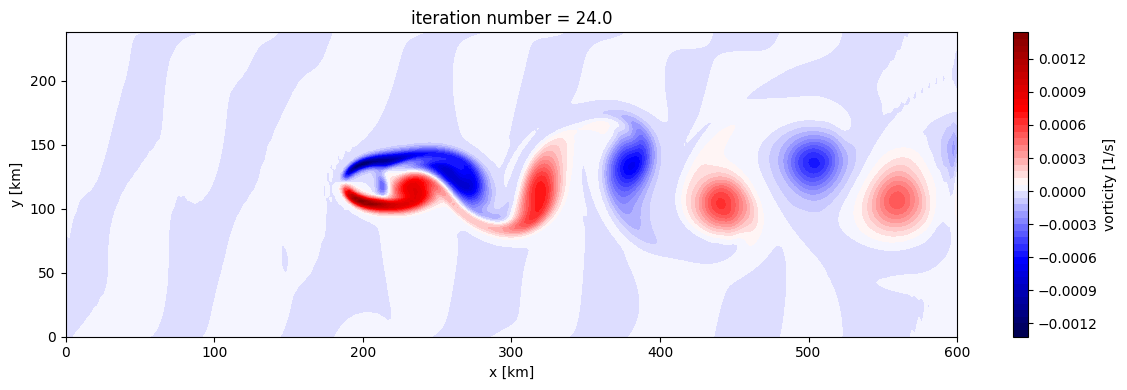

12500


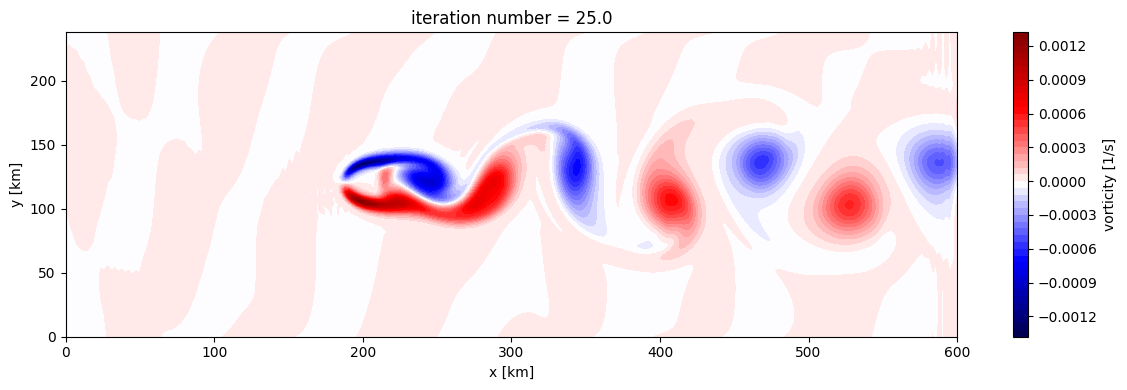

13000


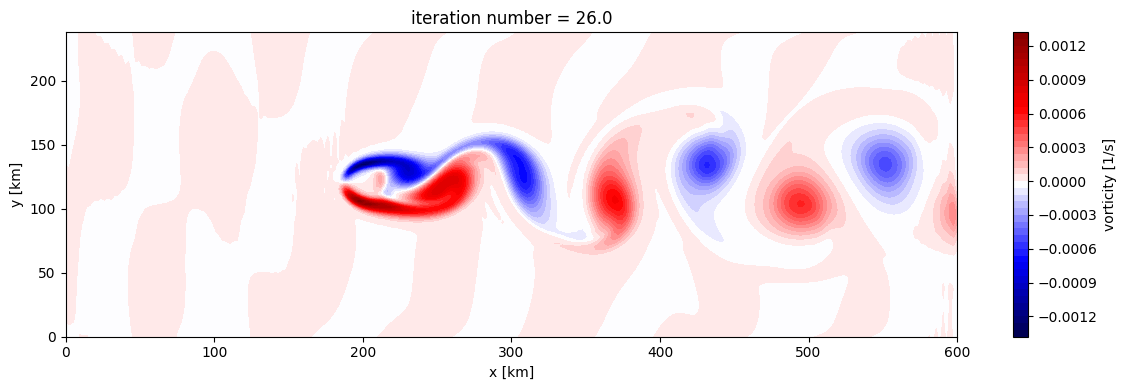

13500


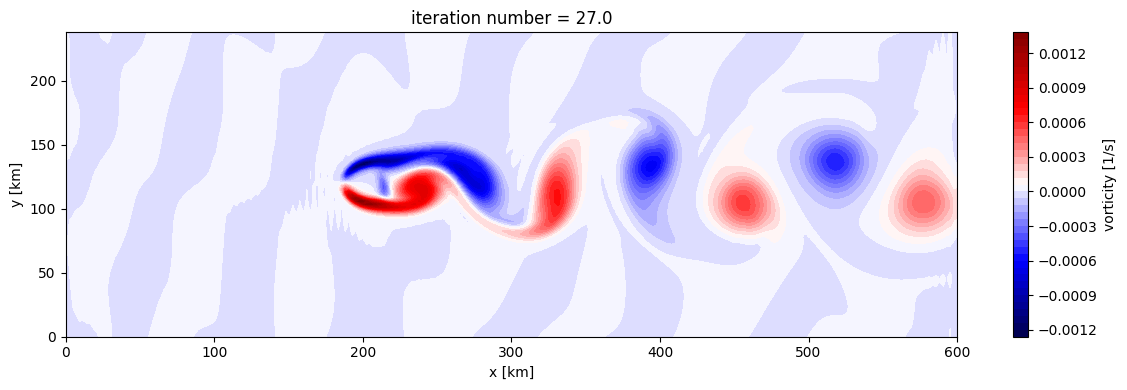

14000


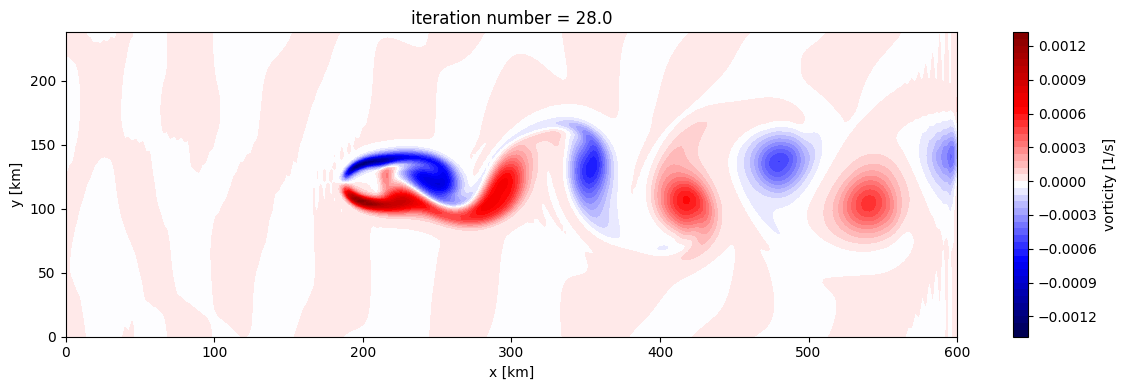

14500


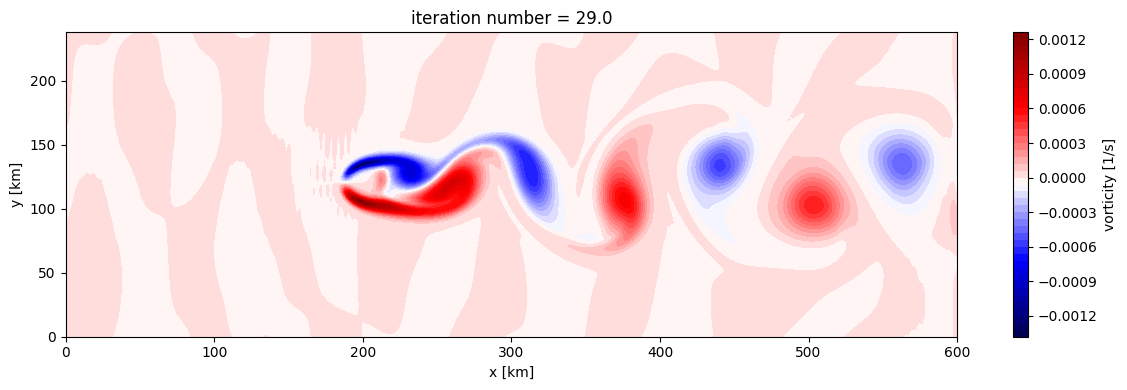

15000


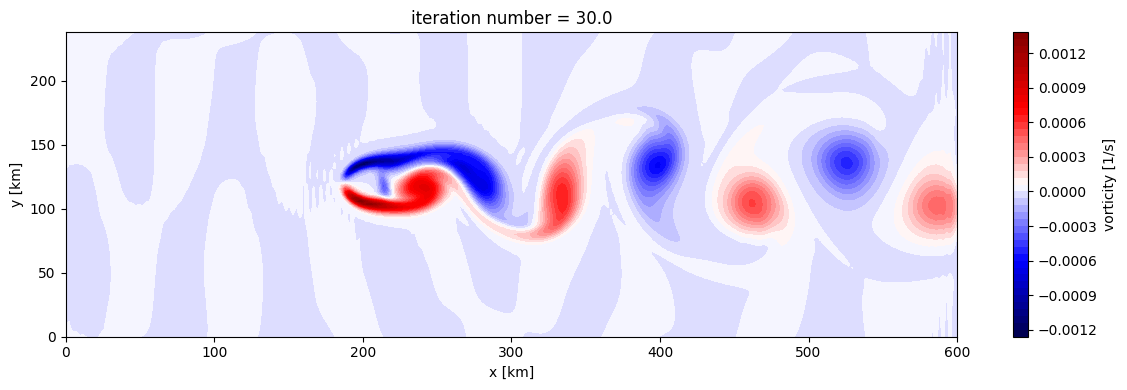

15500


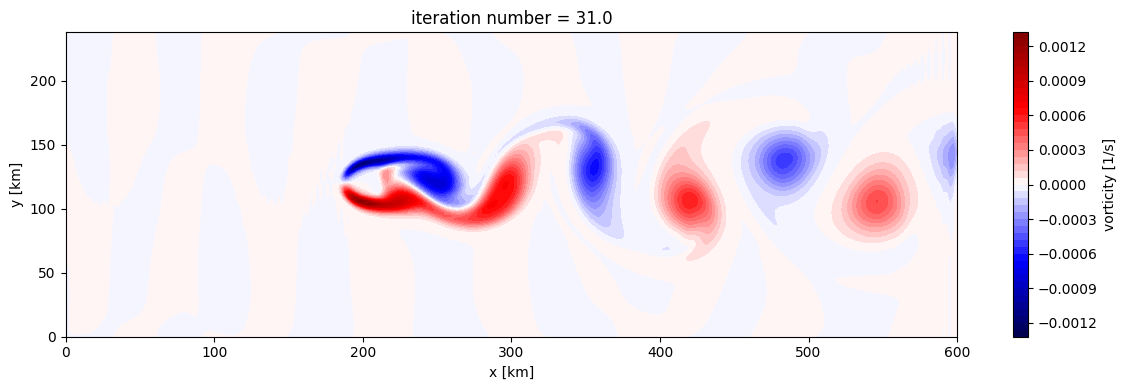

16000


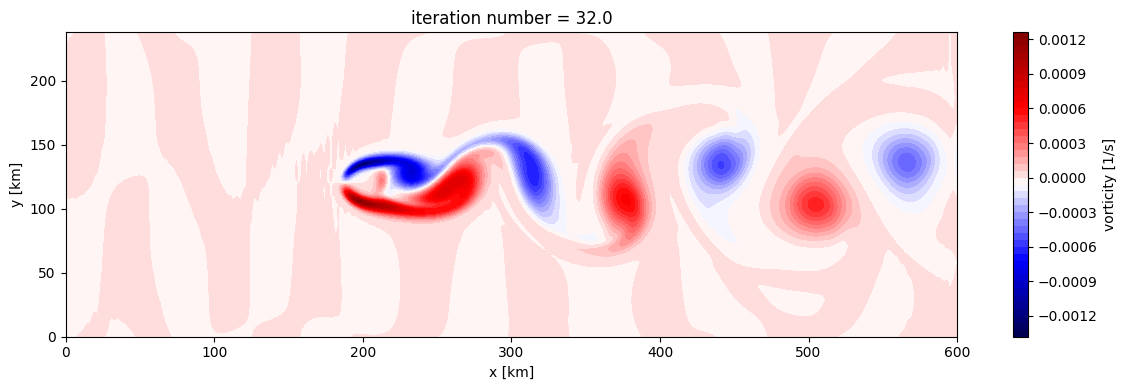

16500


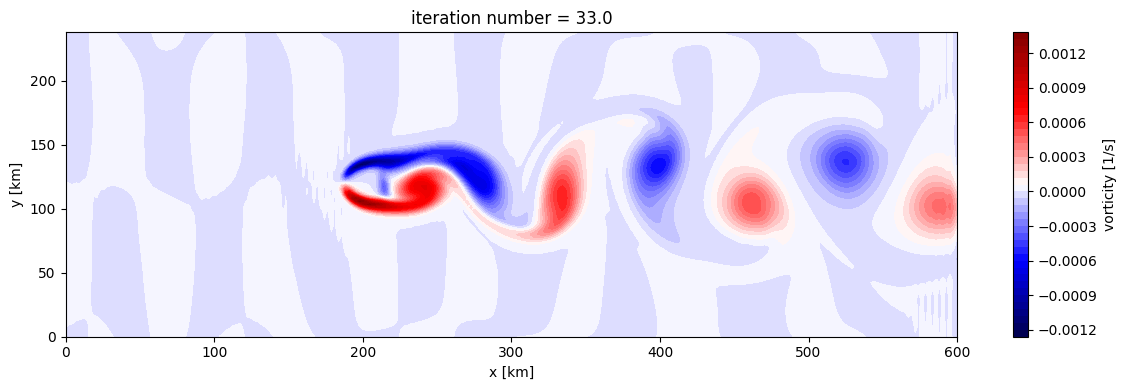

17000


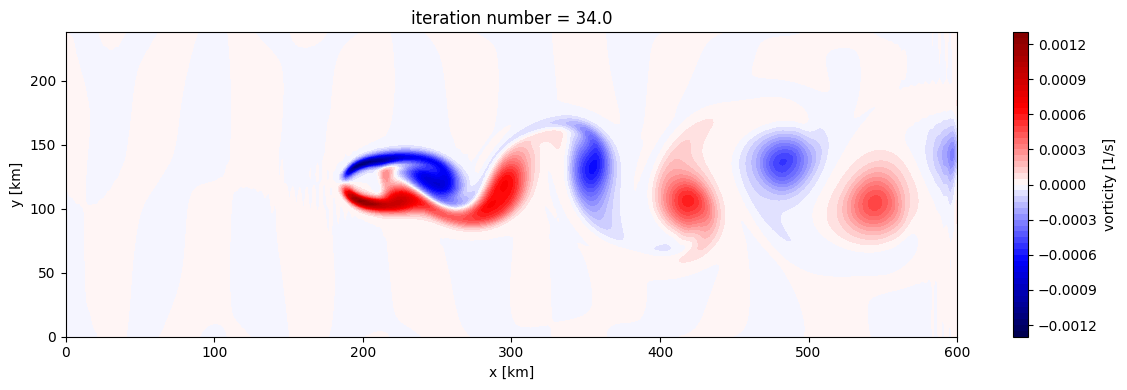

17500


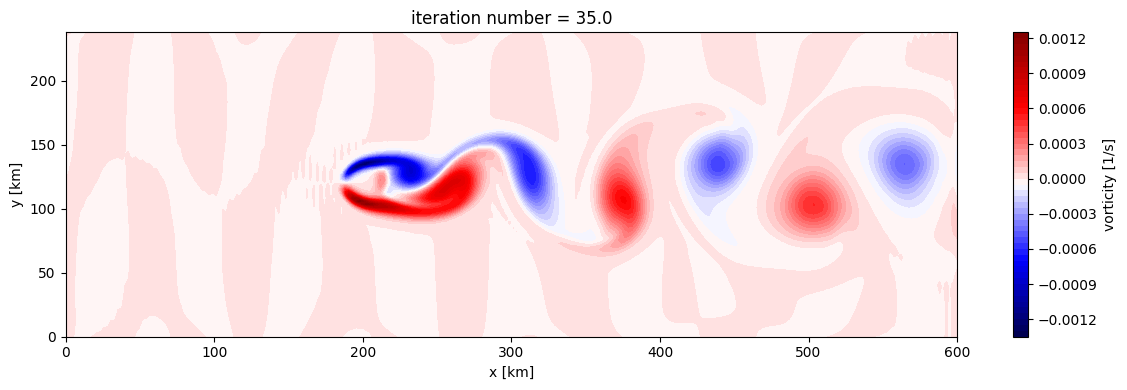

18000


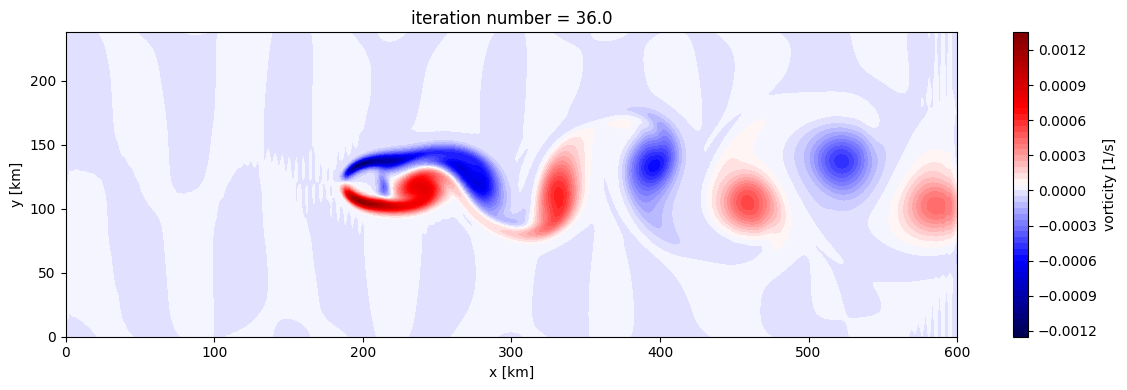

18500


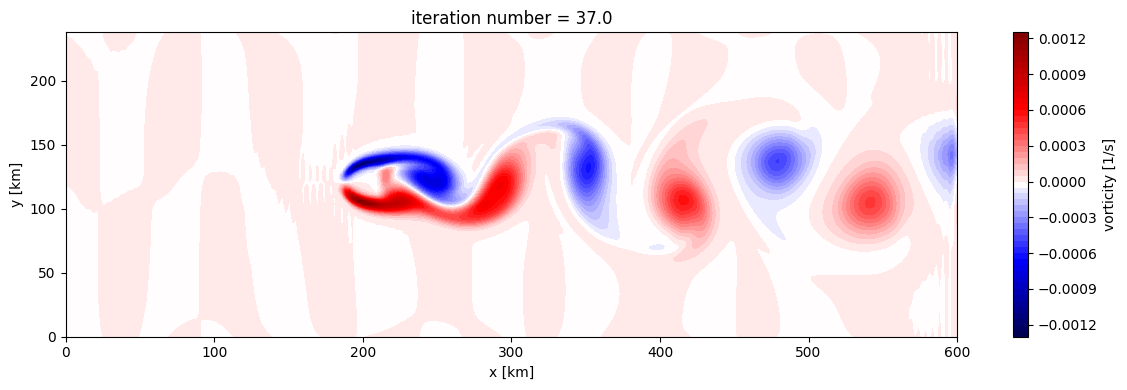

19000


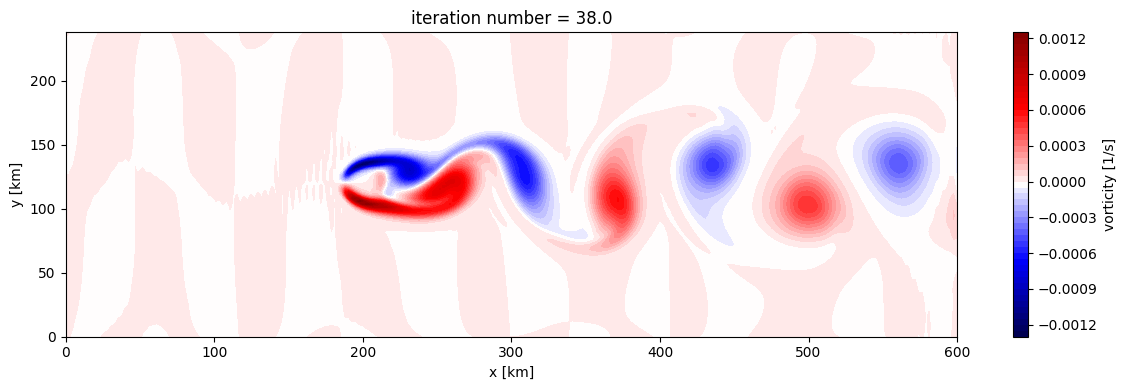

19500


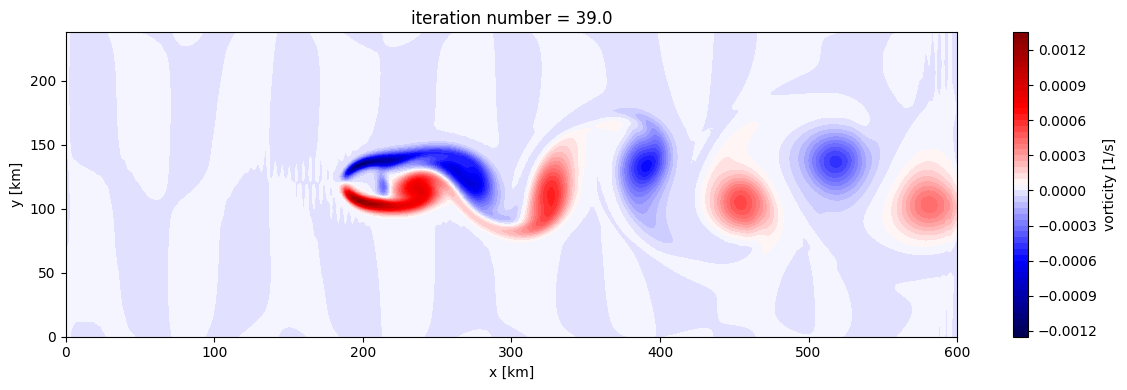

20000


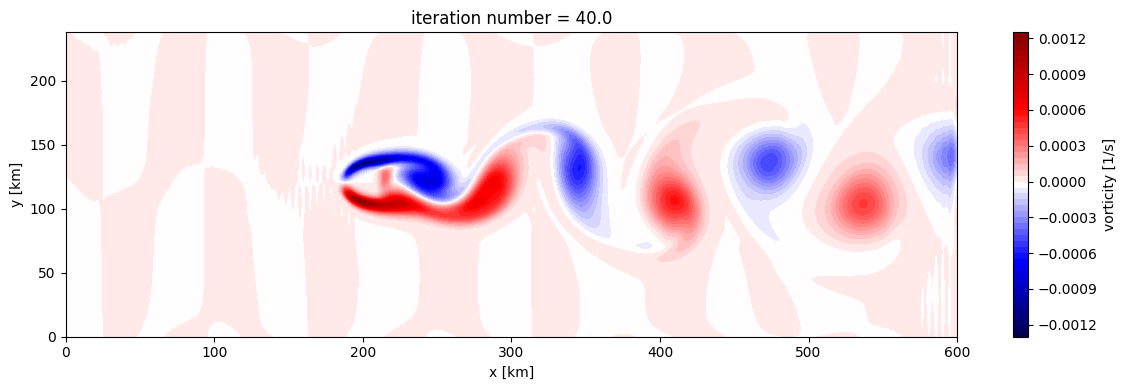

20500


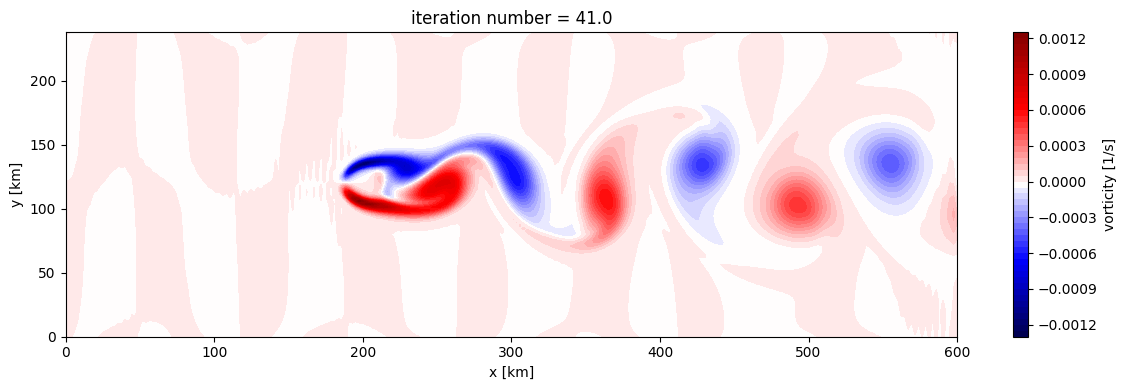

21000


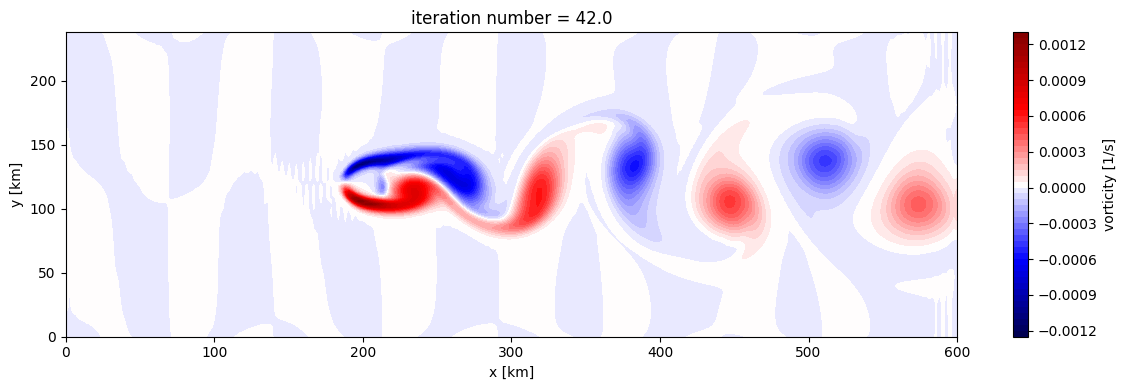

21500


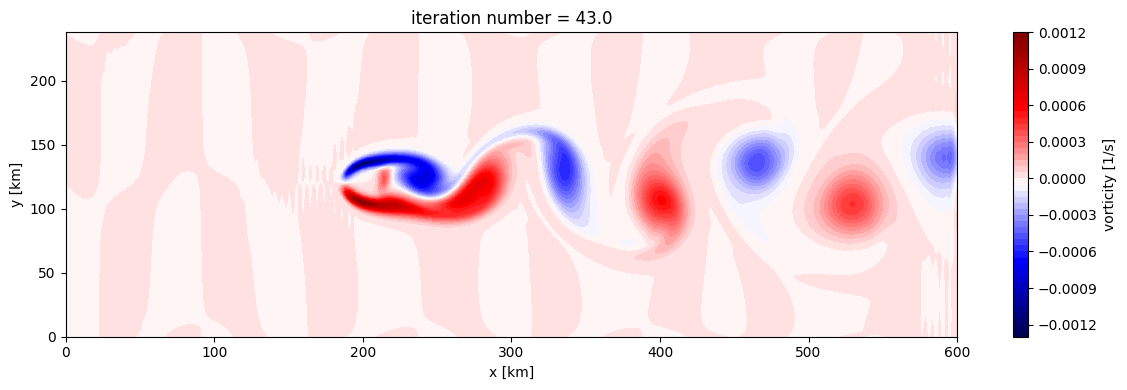

22000


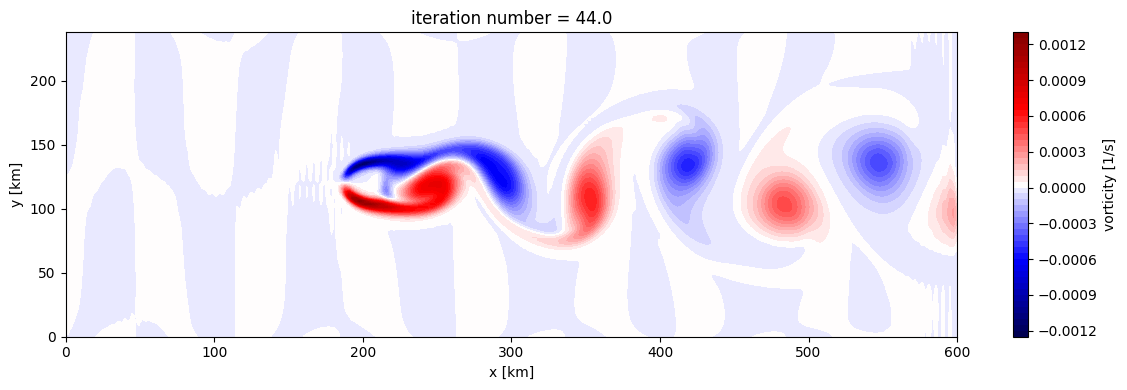

22500


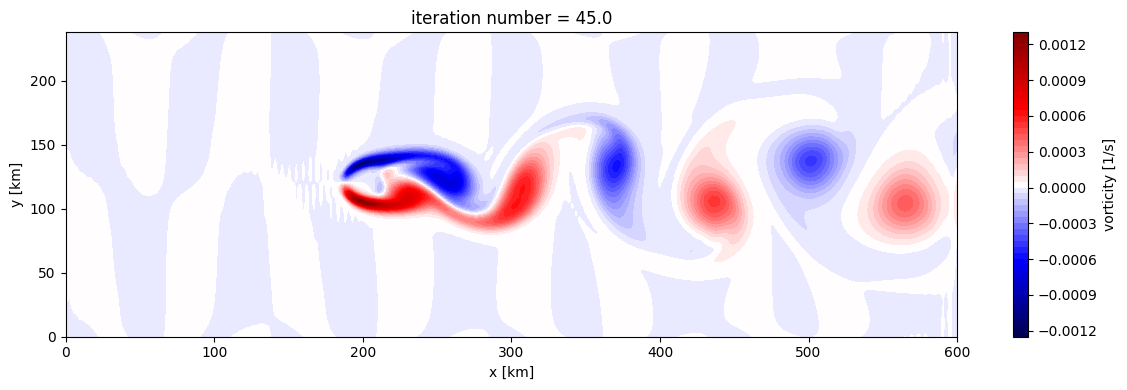

23000


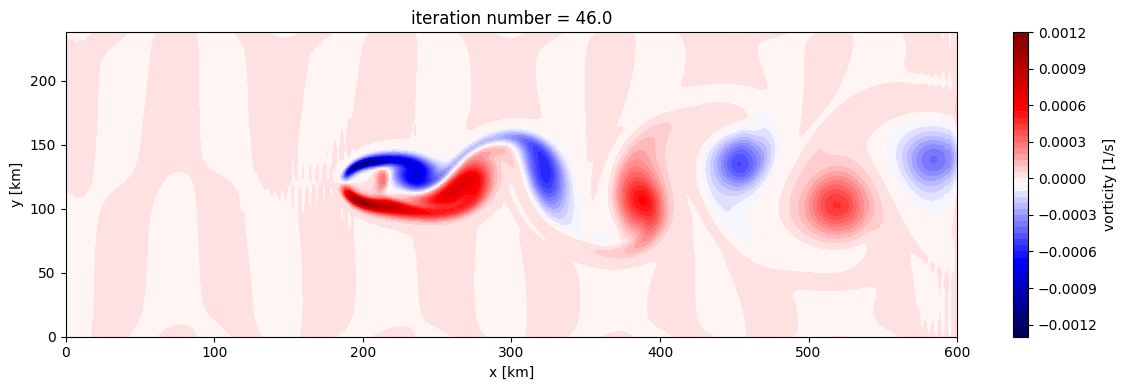

23500


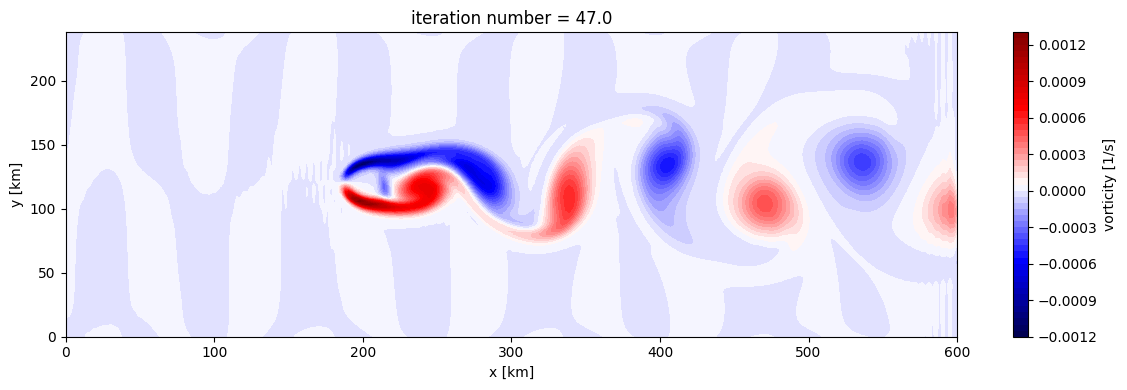

24000


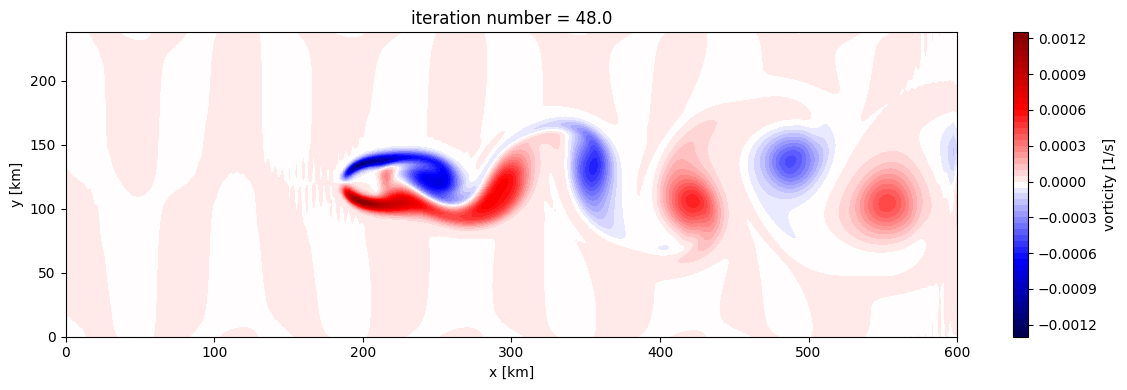

24500


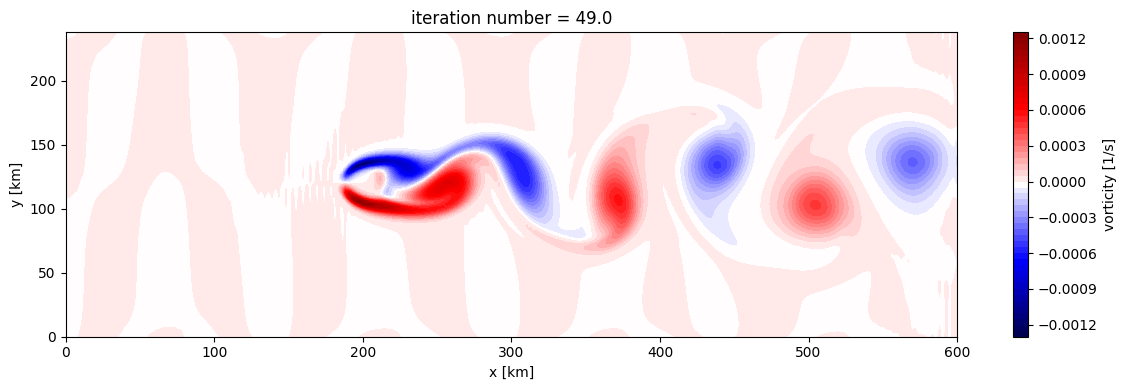

25000


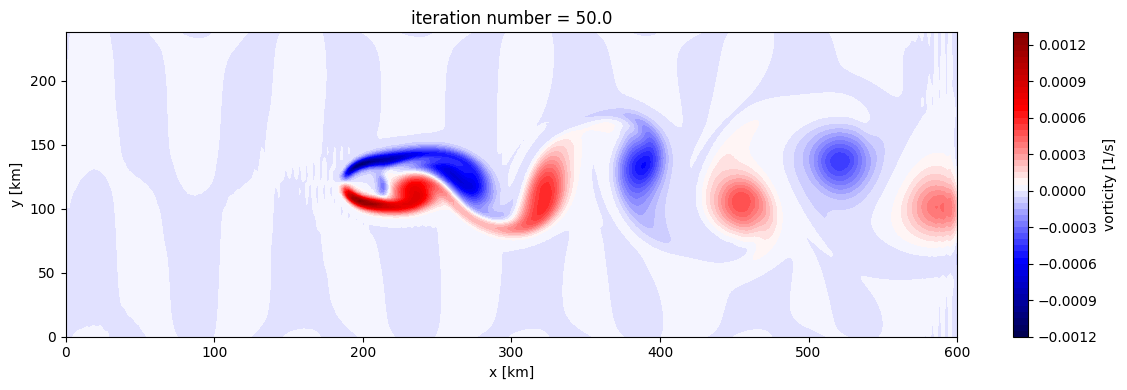

25500


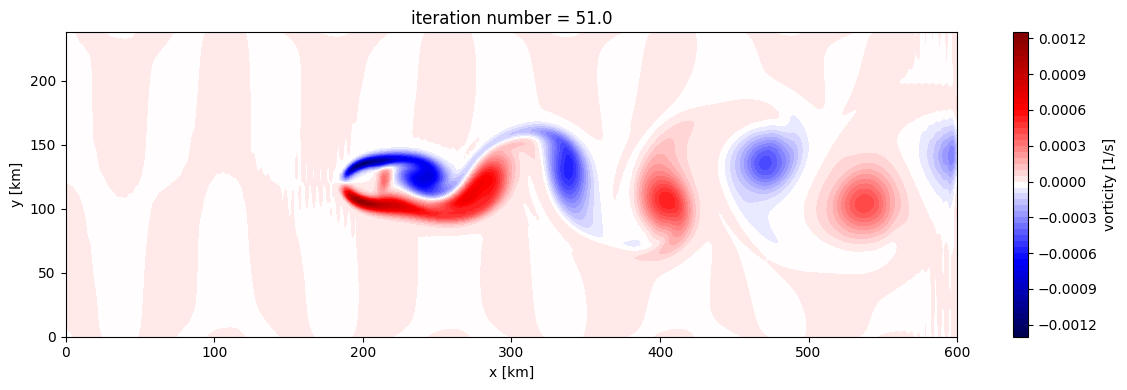

26000


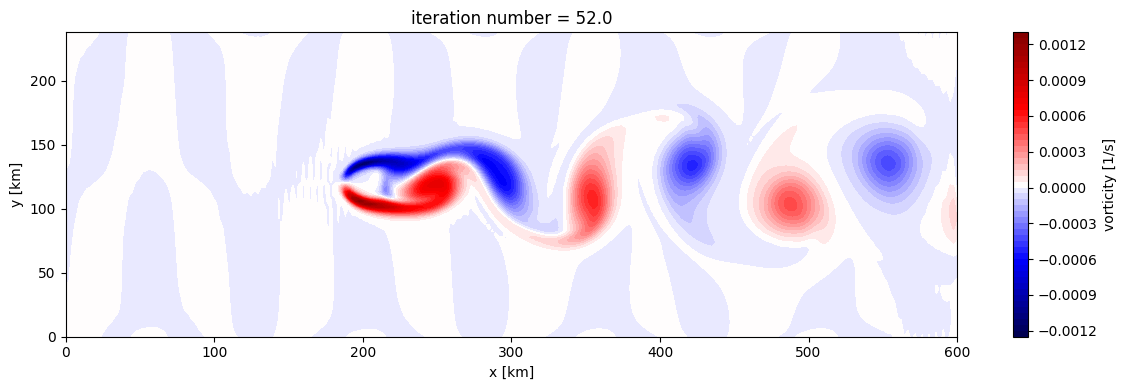

26500


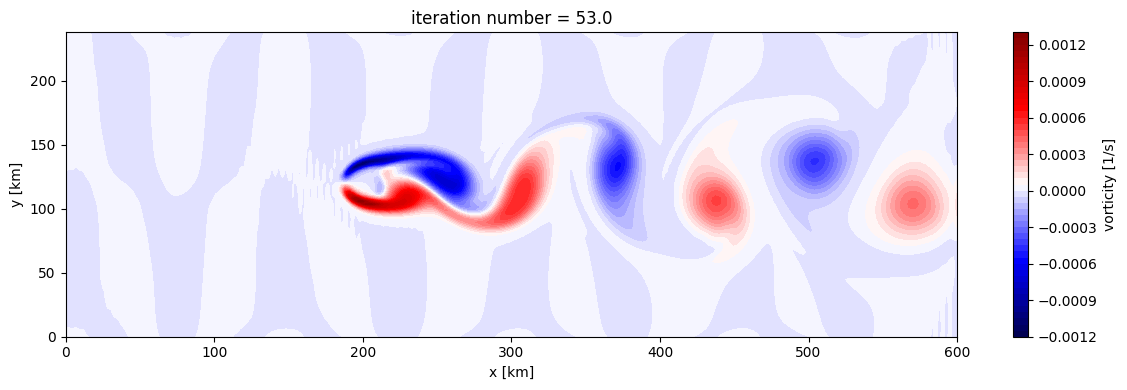

27000


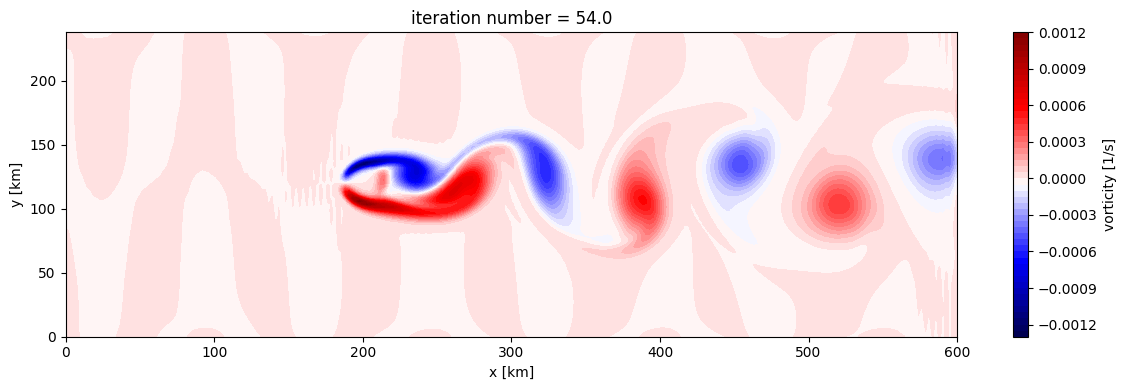

27500


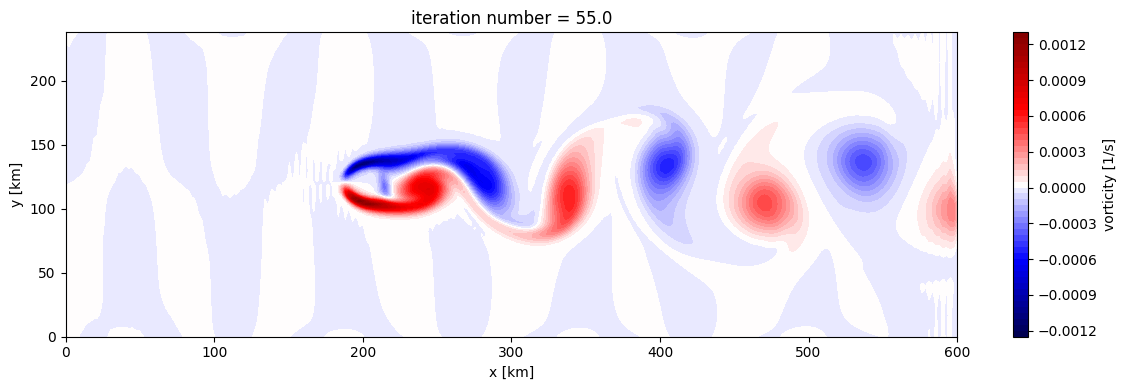

28000


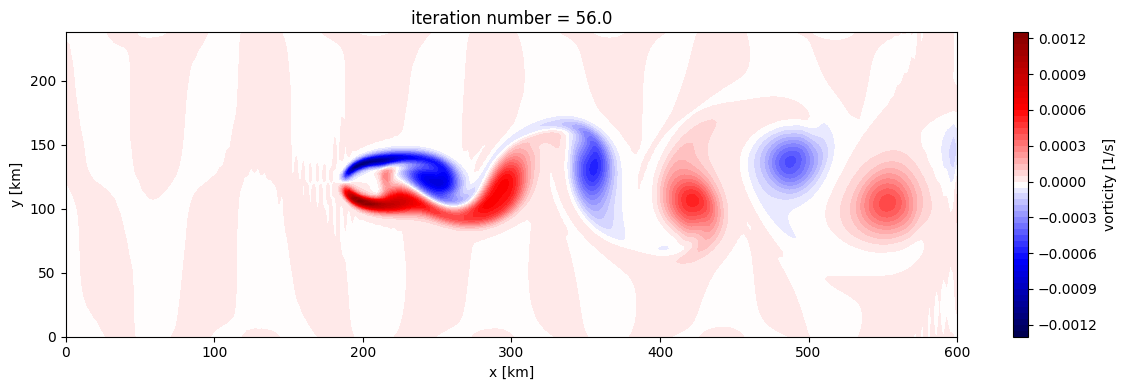

28500


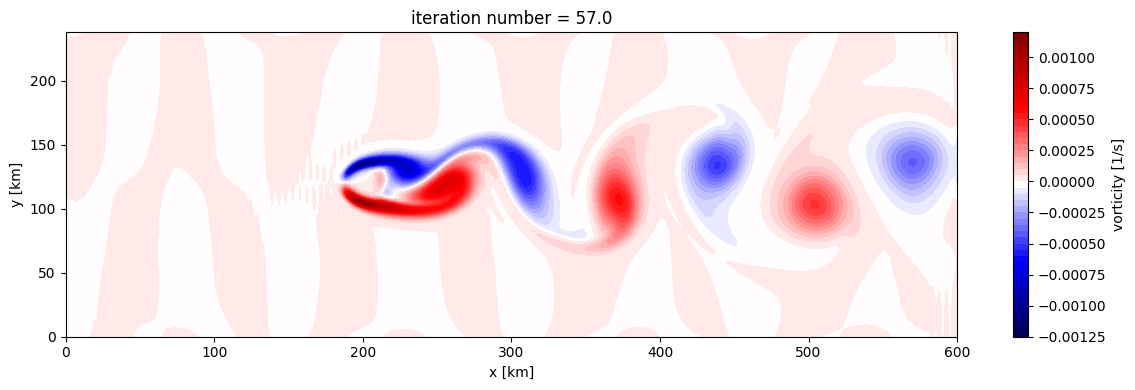

29000


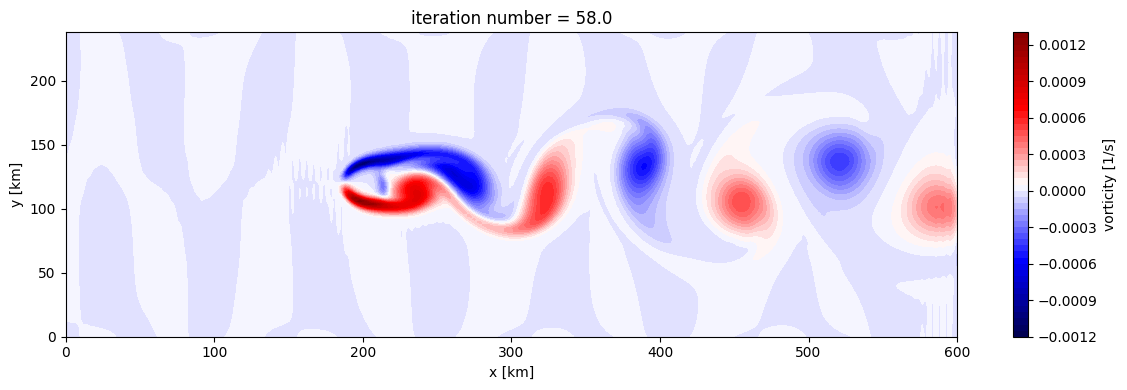

29500


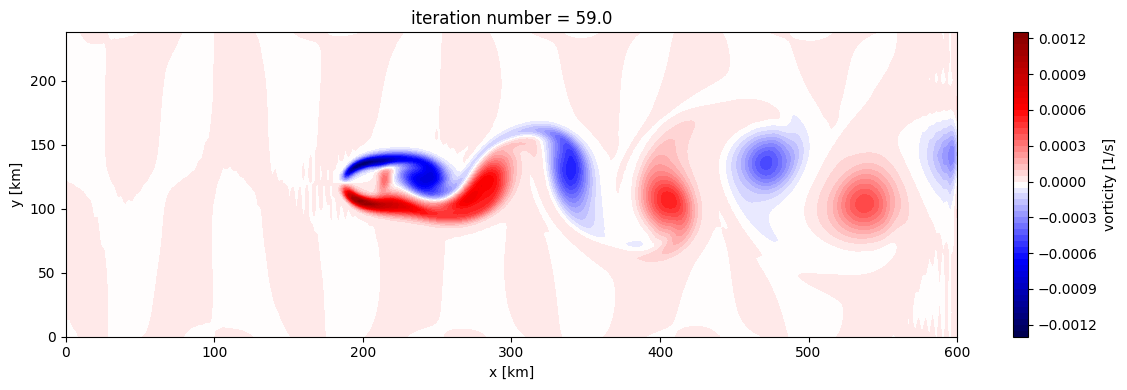

30000


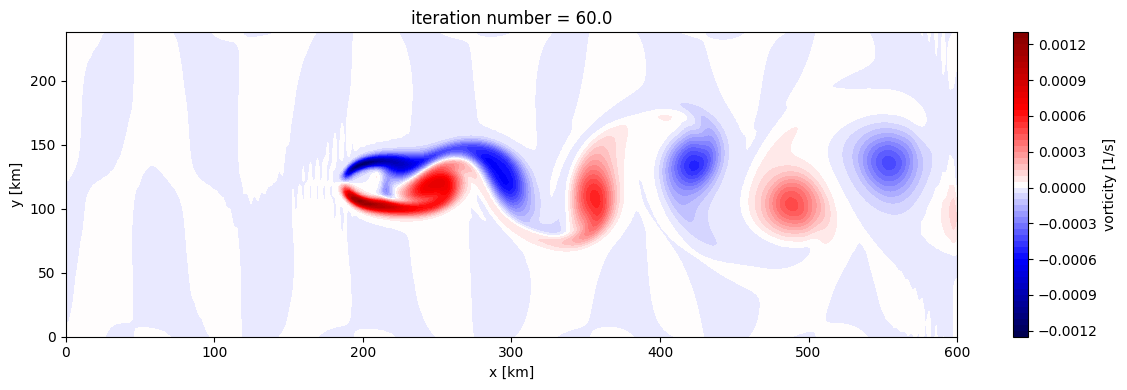

30500


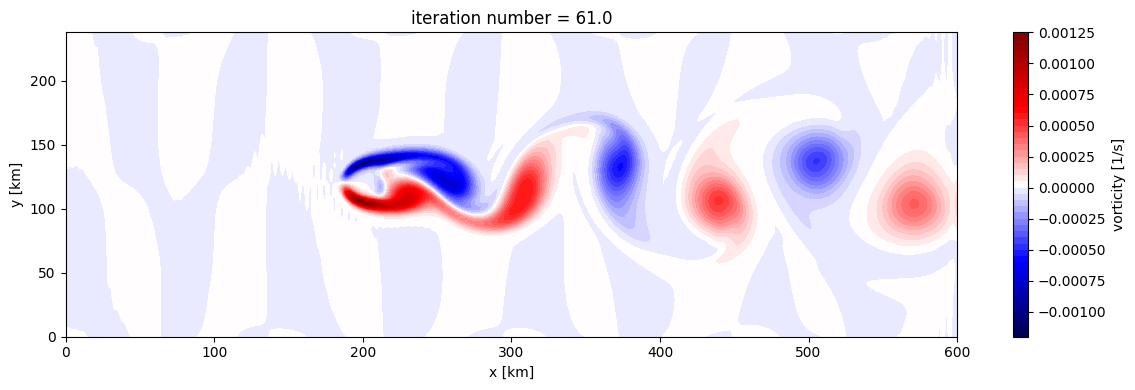

31000


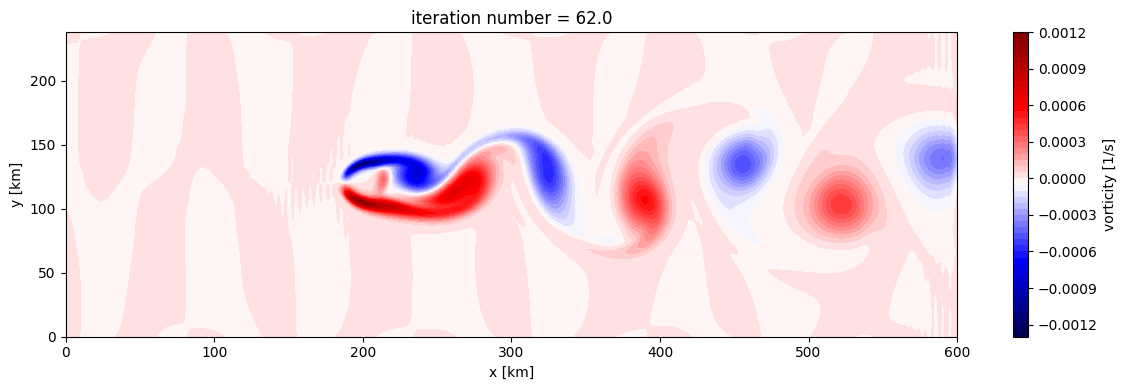

31500


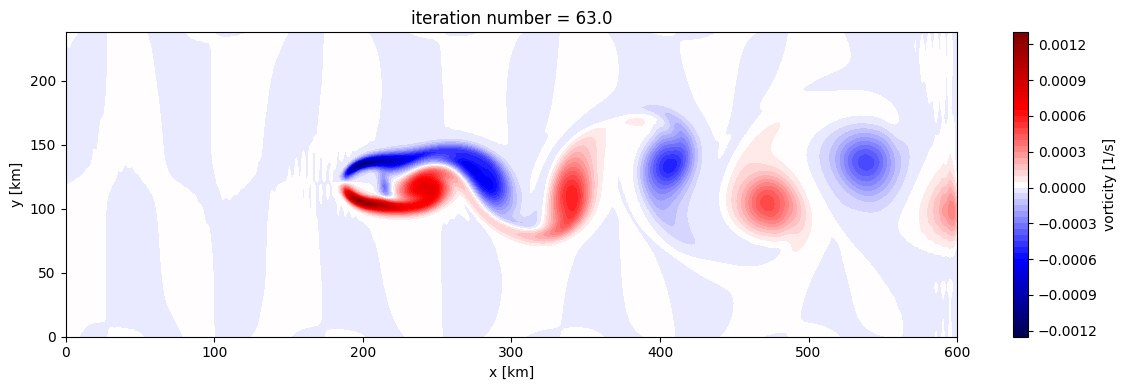

32000


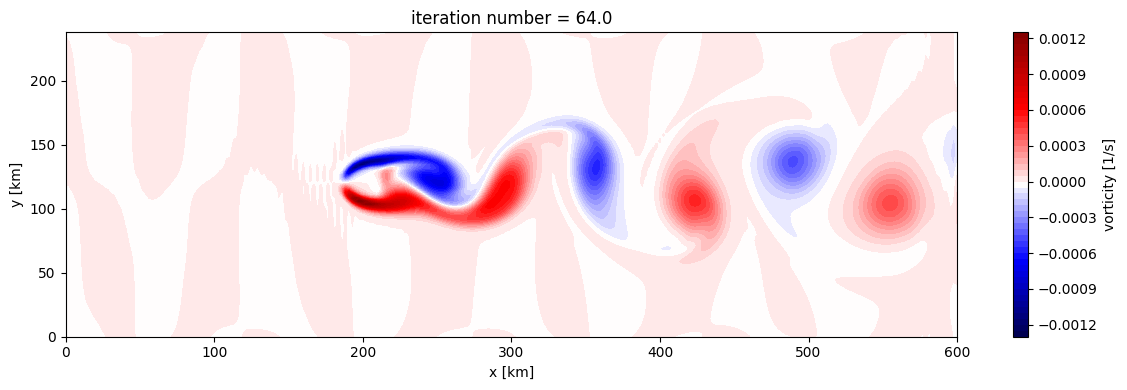

32500


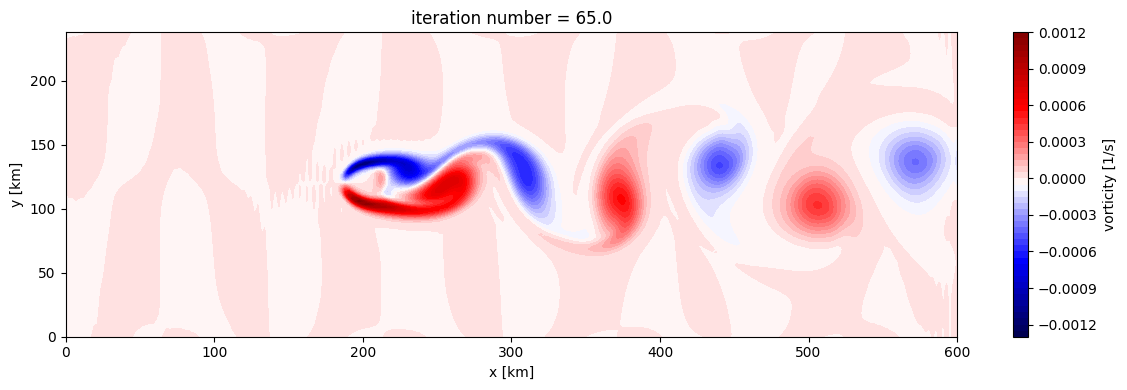

33000


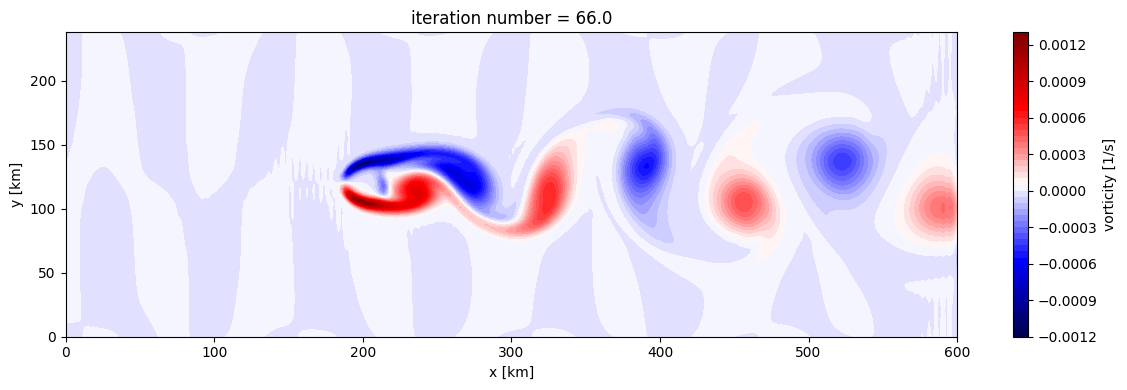

33500


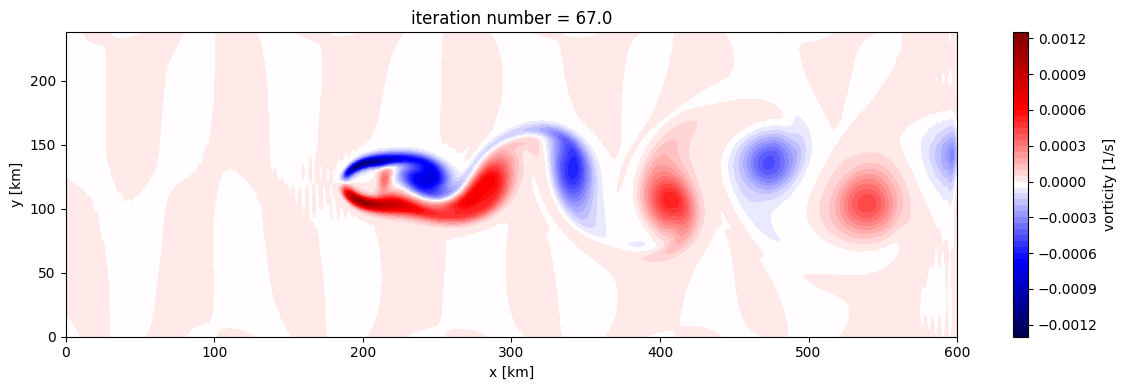

34000


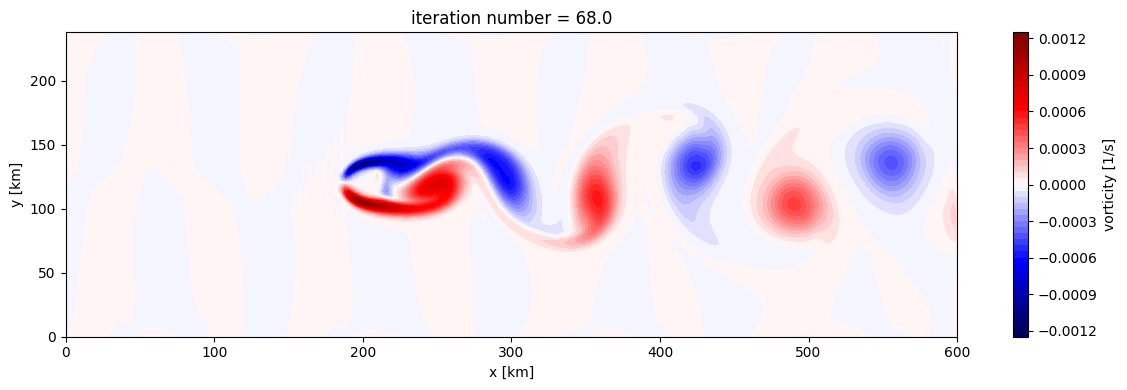

34500


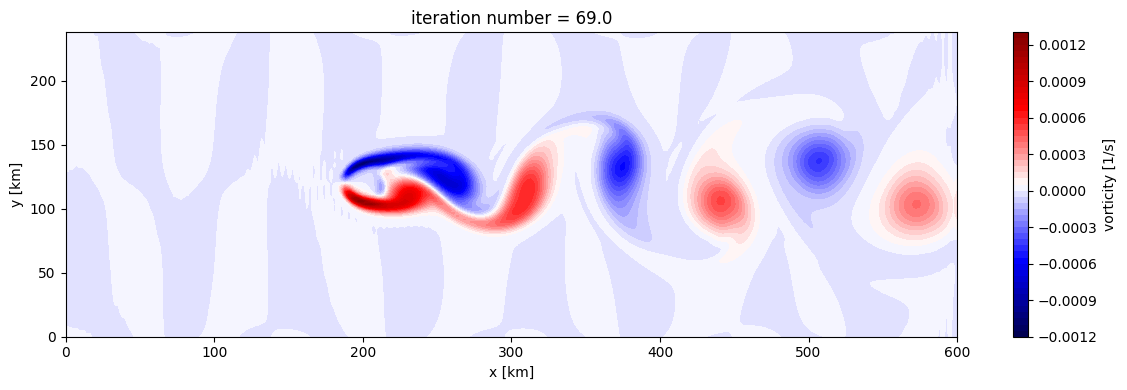

35000


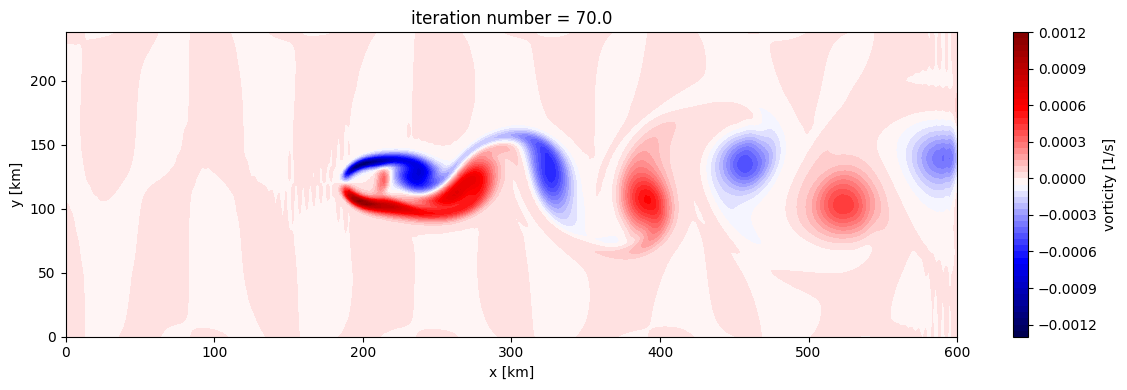

35500


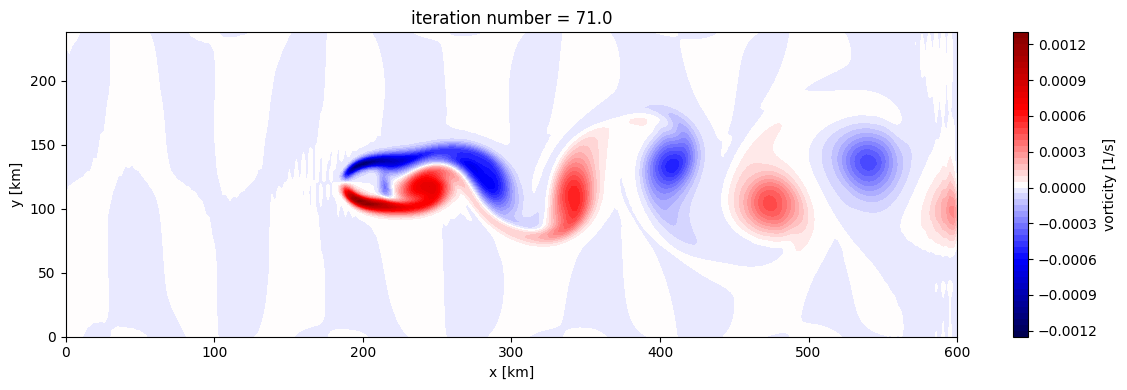

36000


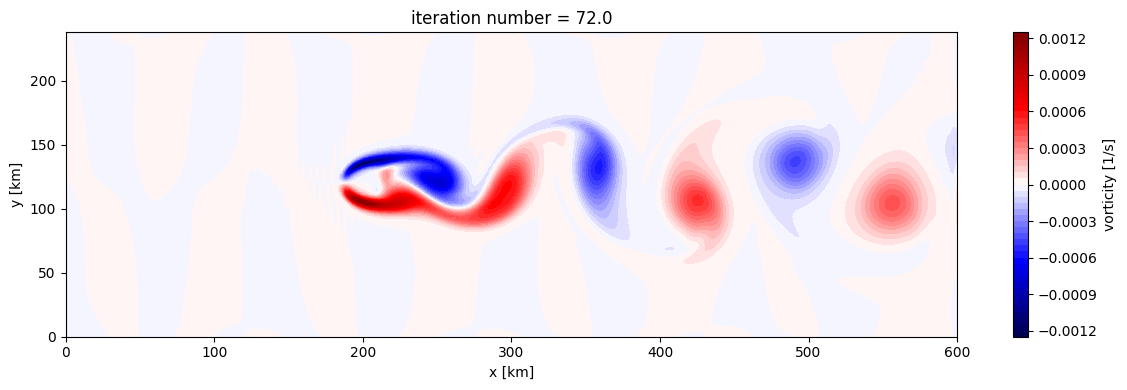

36500


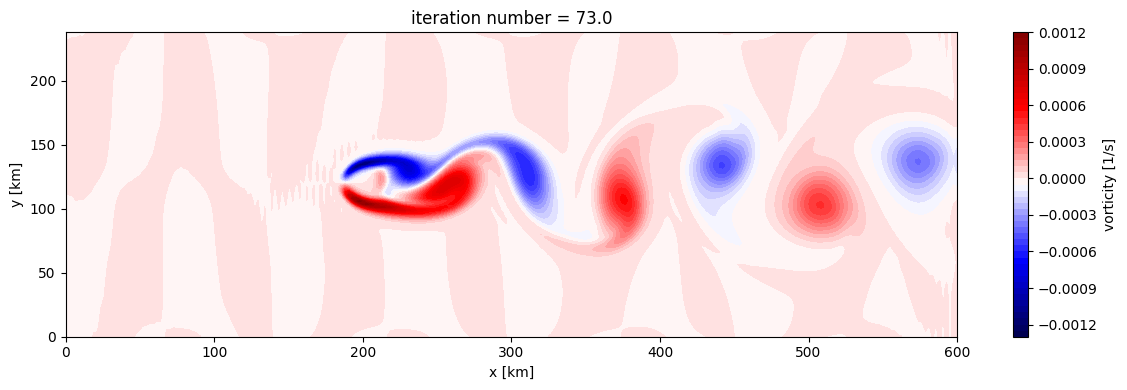

37000


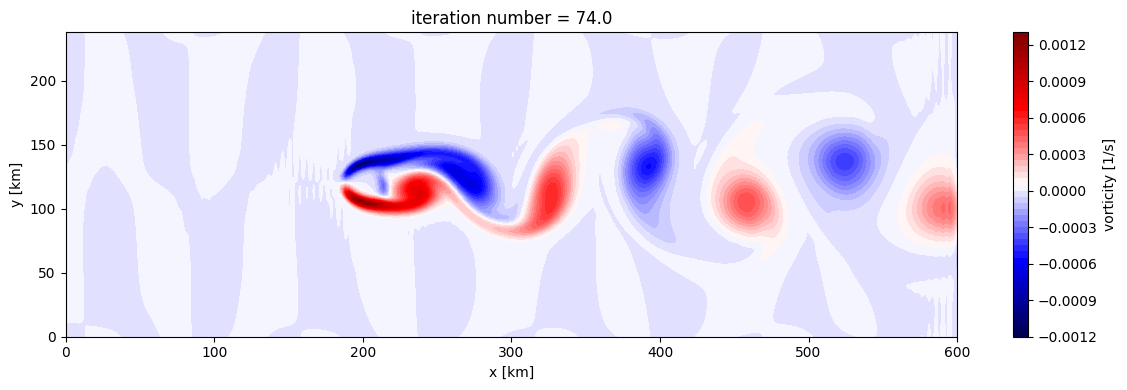

37500


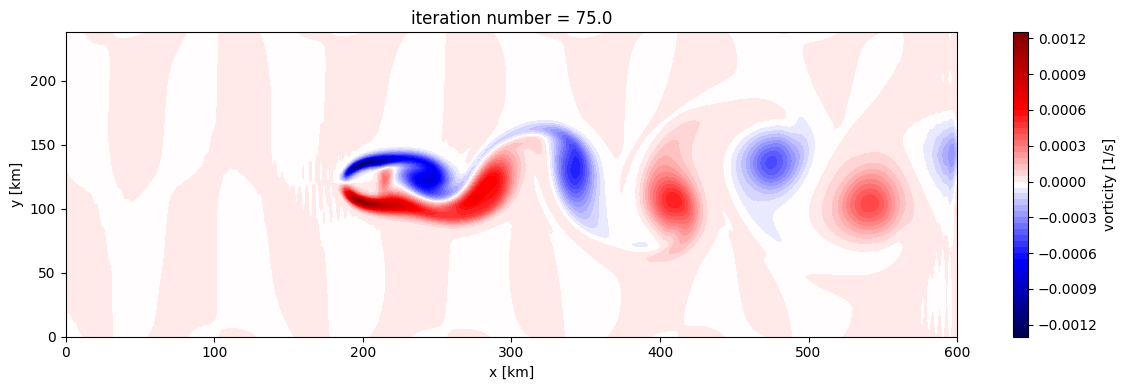

38000


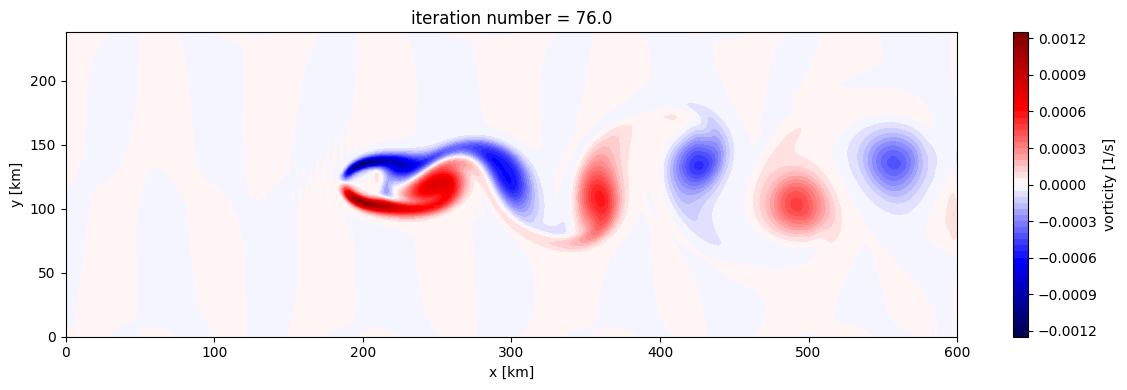

38500


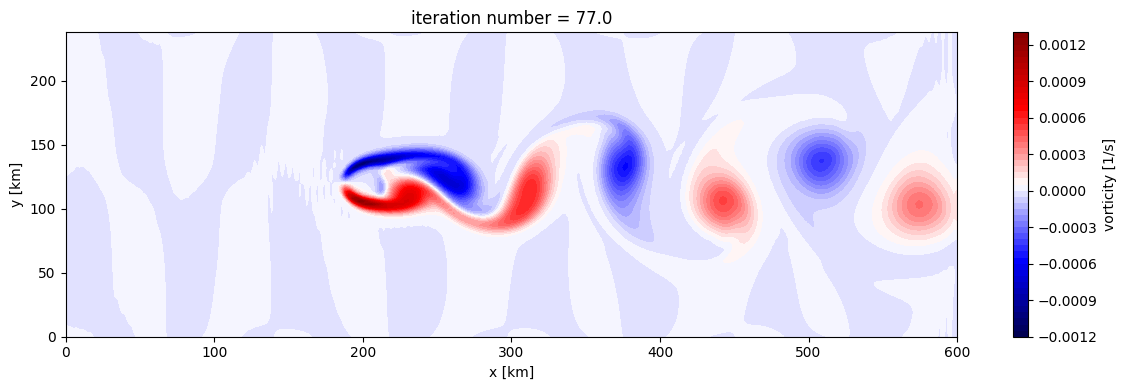

39000


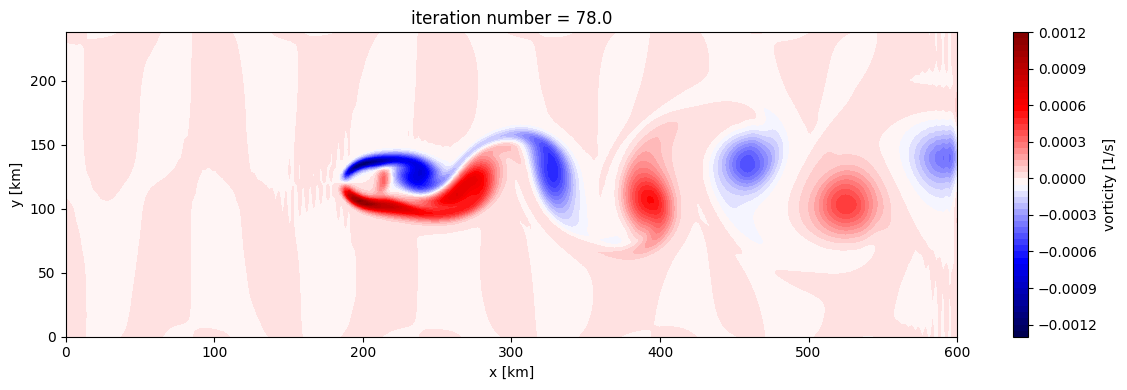

39500


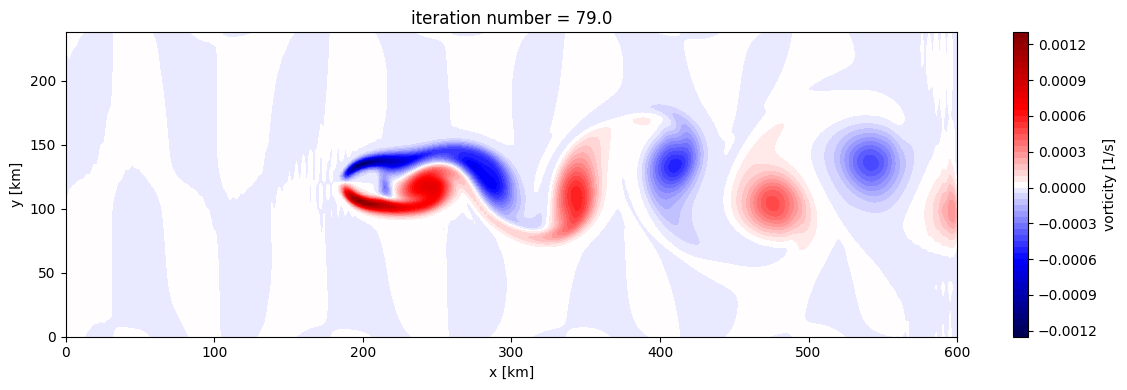

40000


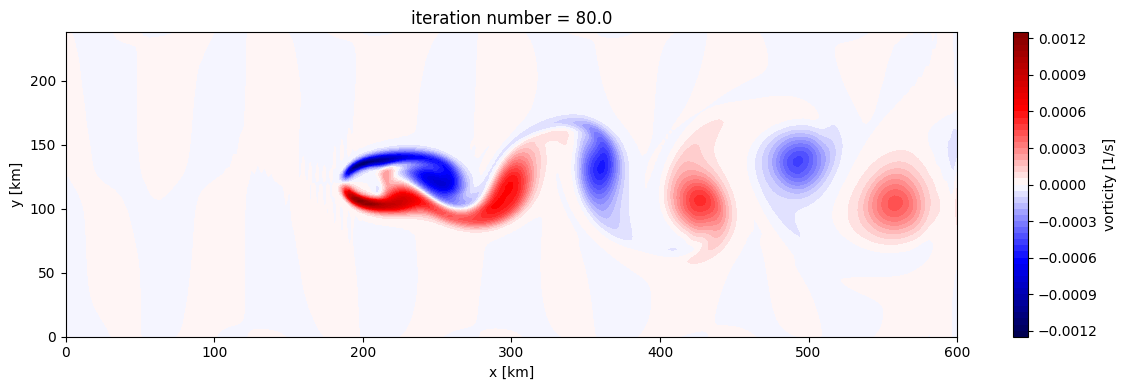

40500


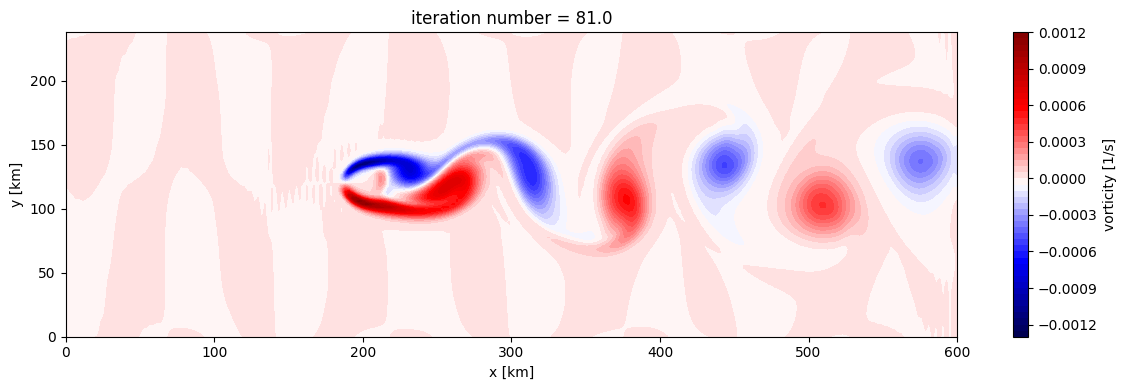

41000


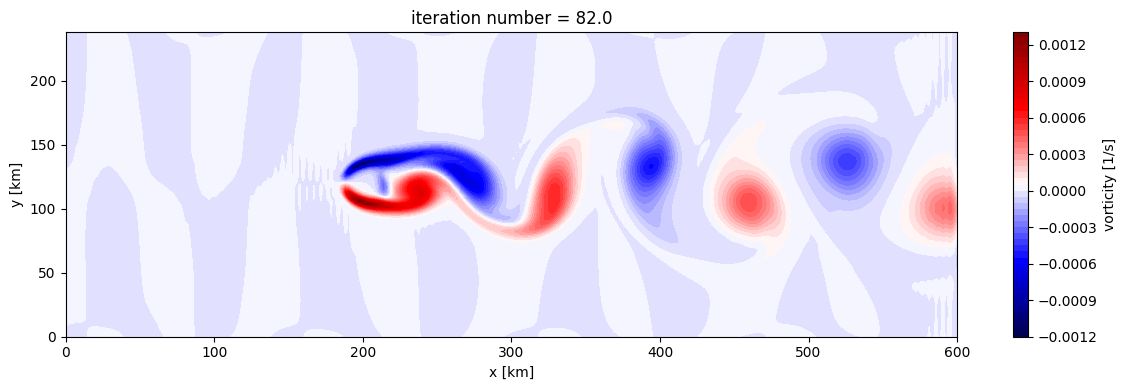

41500


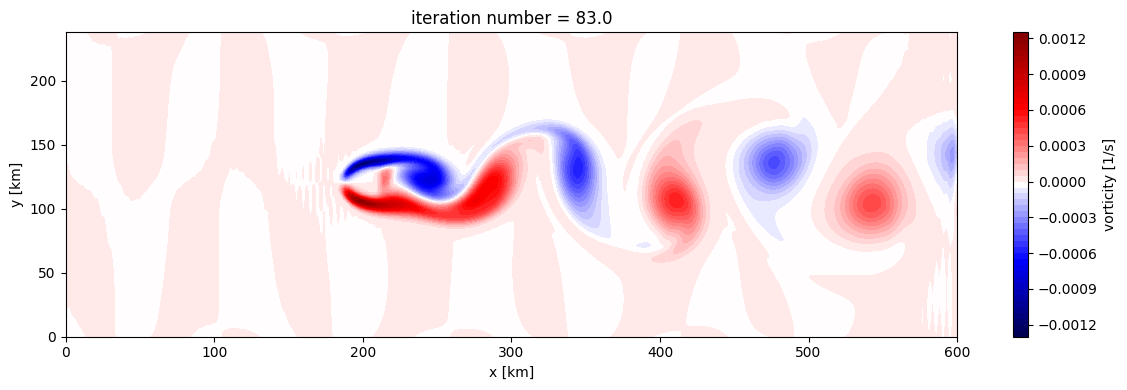

42000


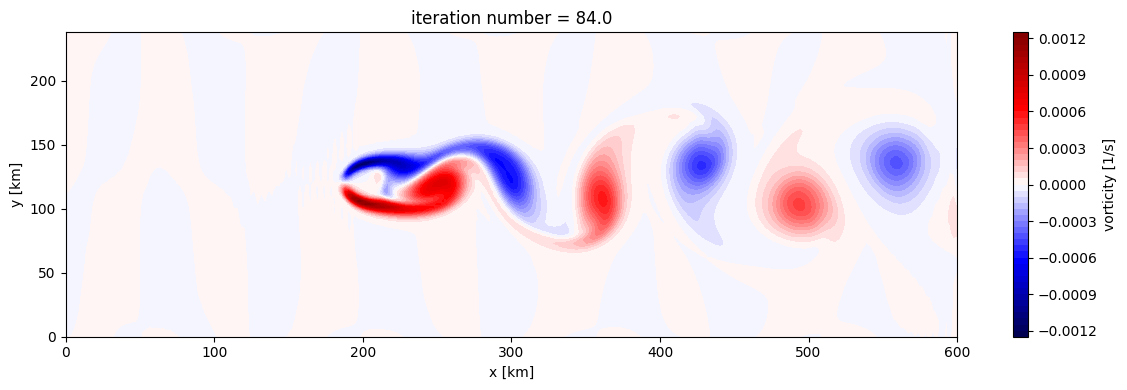

42500


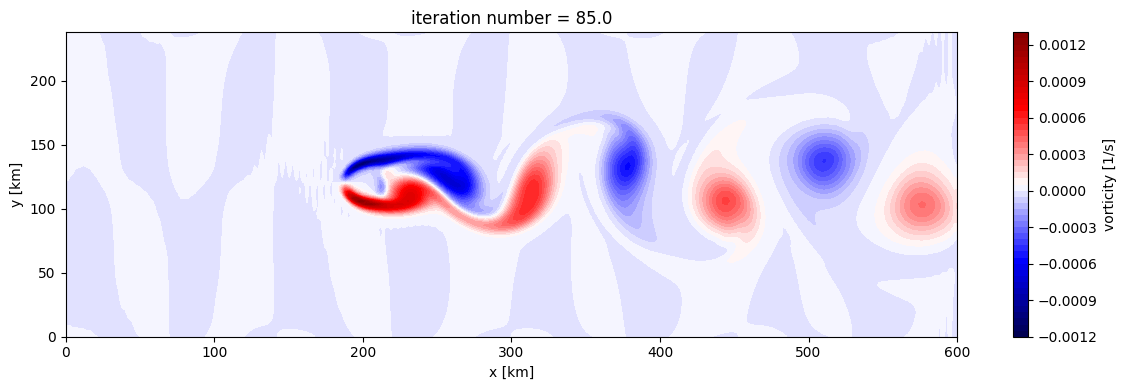

43000


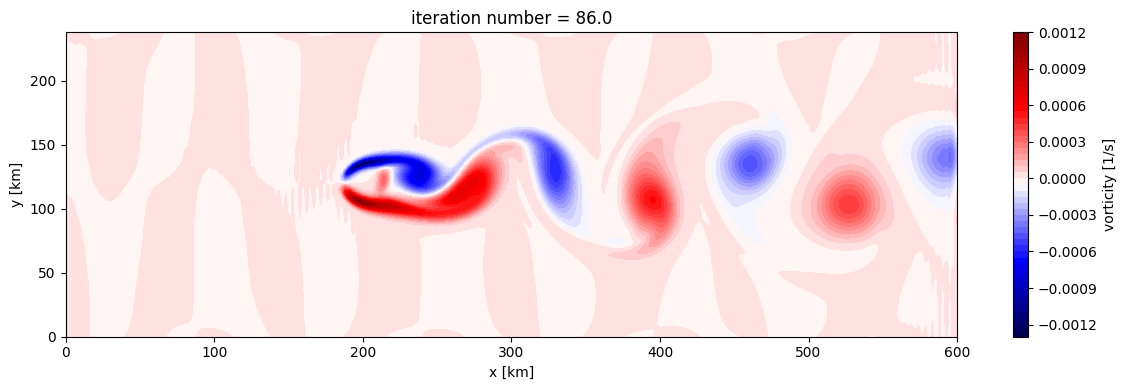

43500


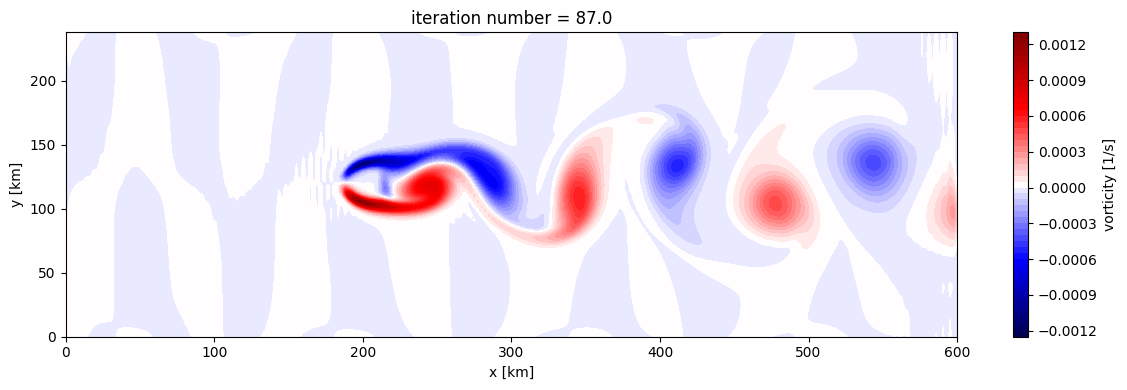

44000


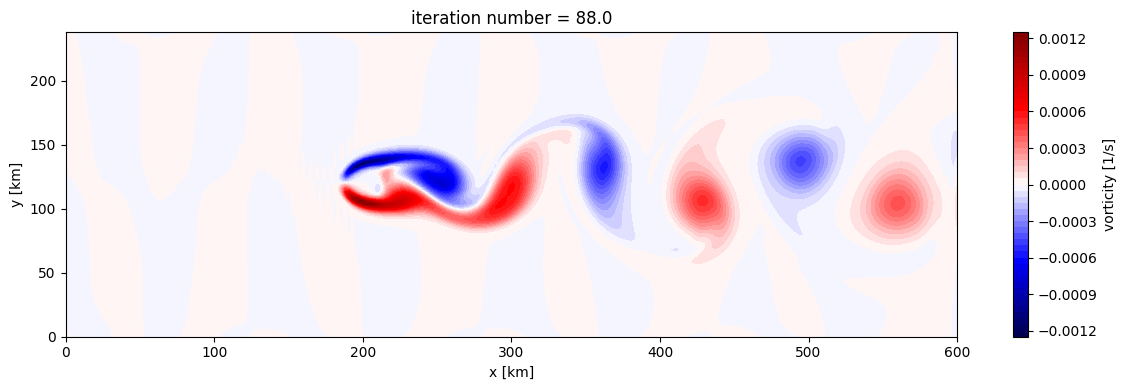

44500


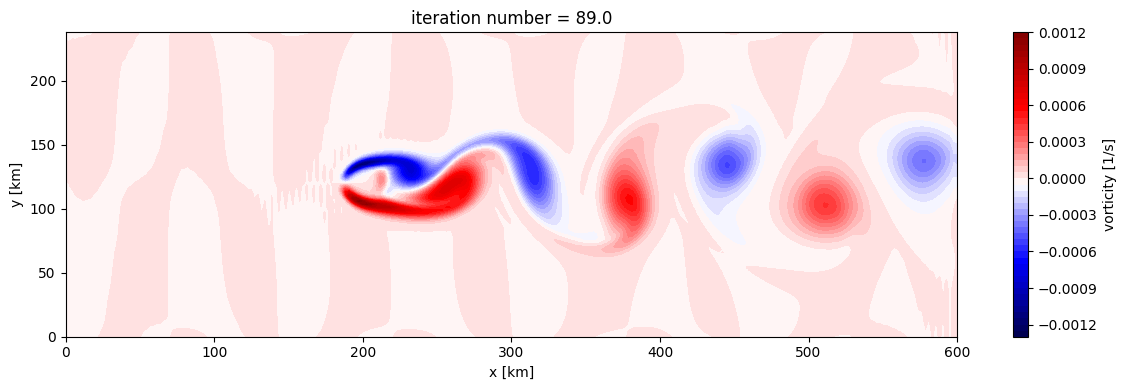

45000


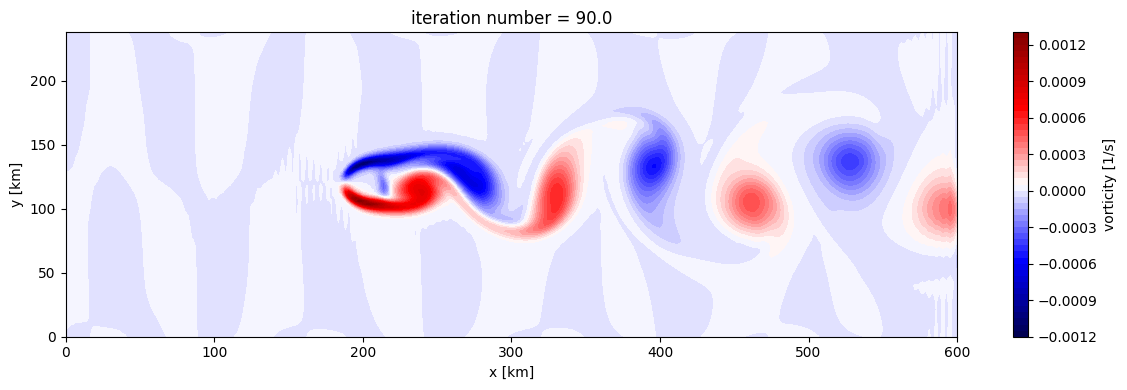

45500


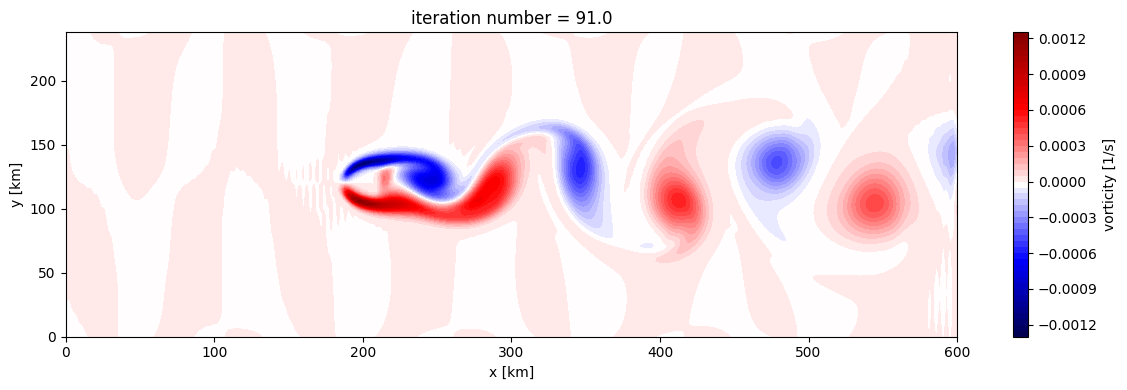

46000


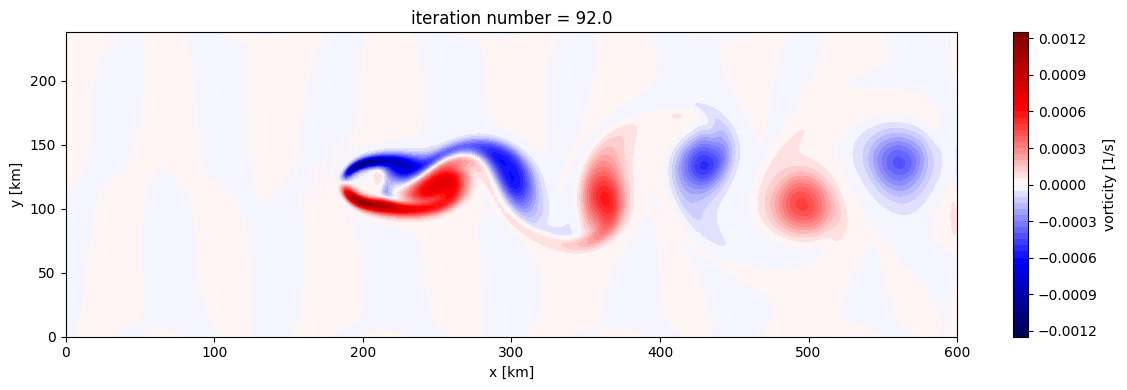

46500


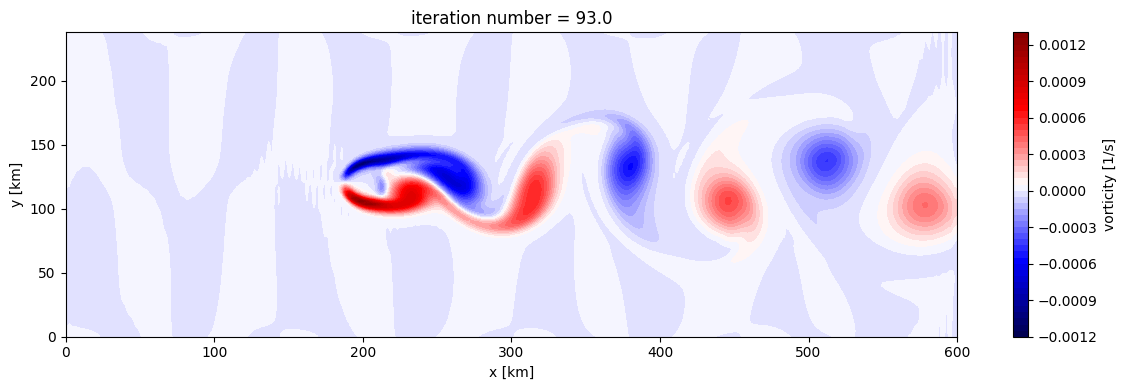

47000


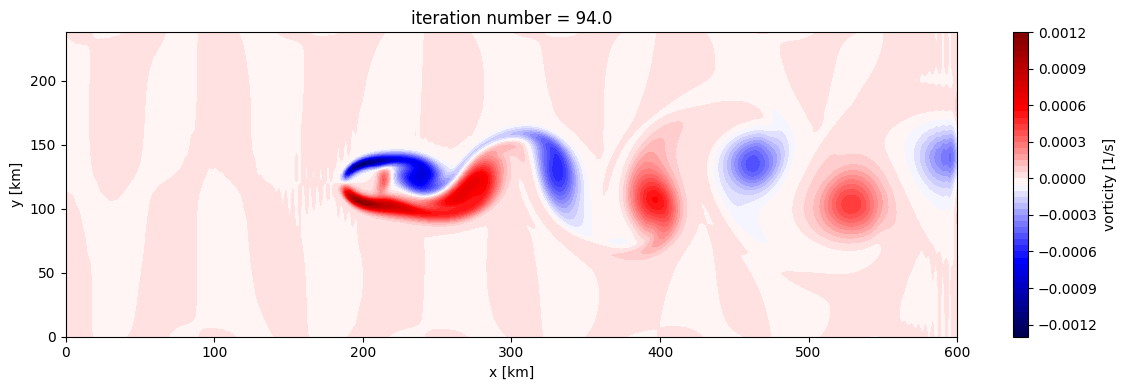

47500


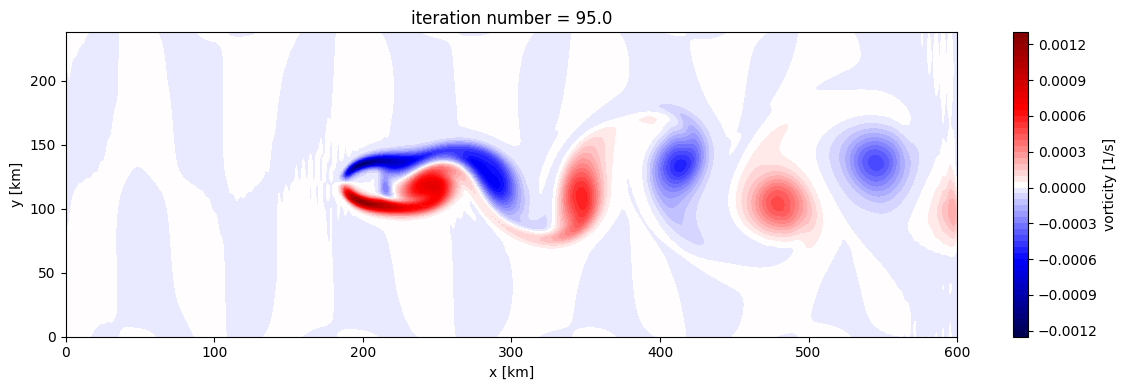

48000


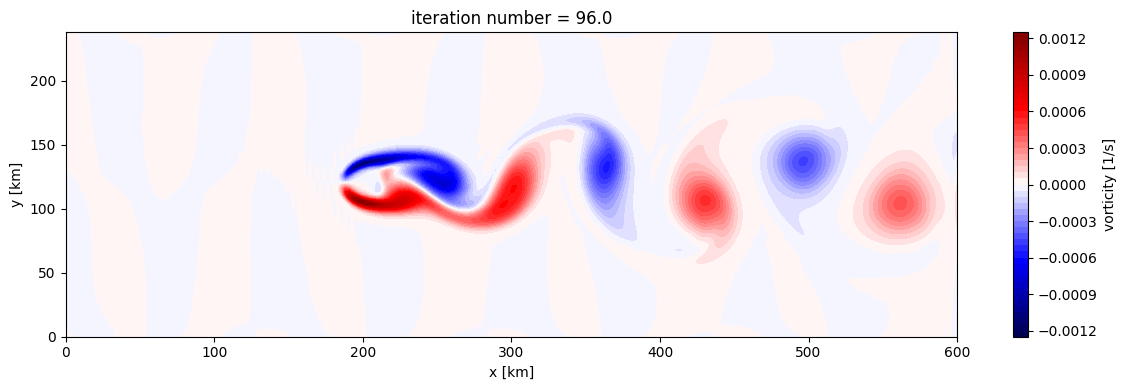

48500


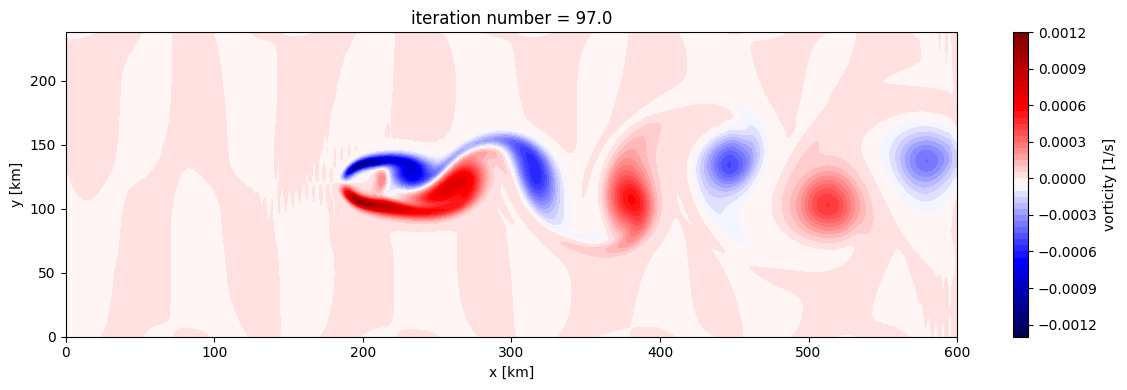

49000


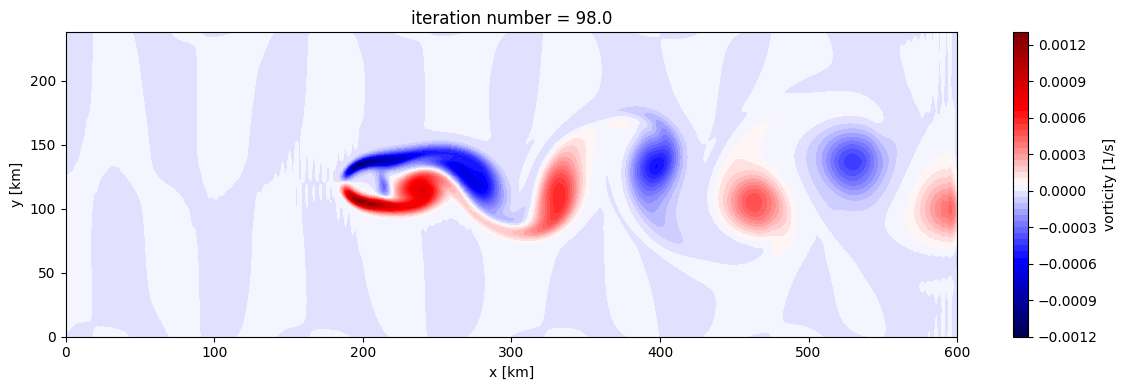

49500


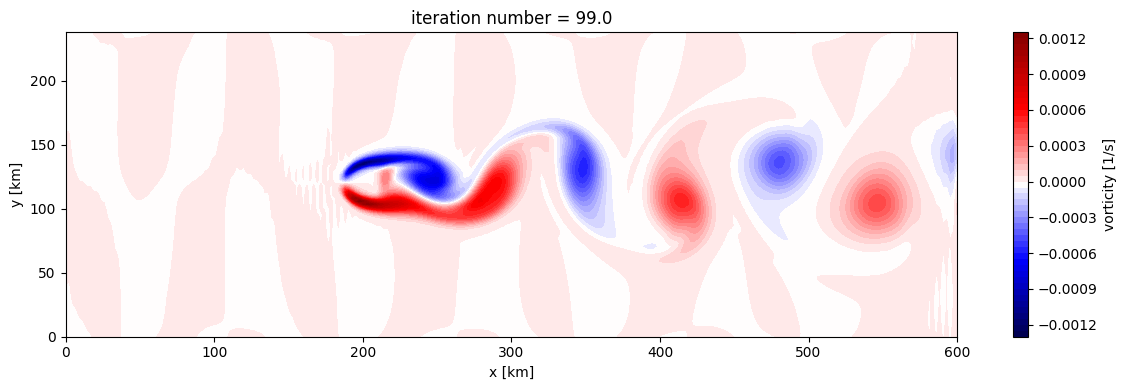

50000


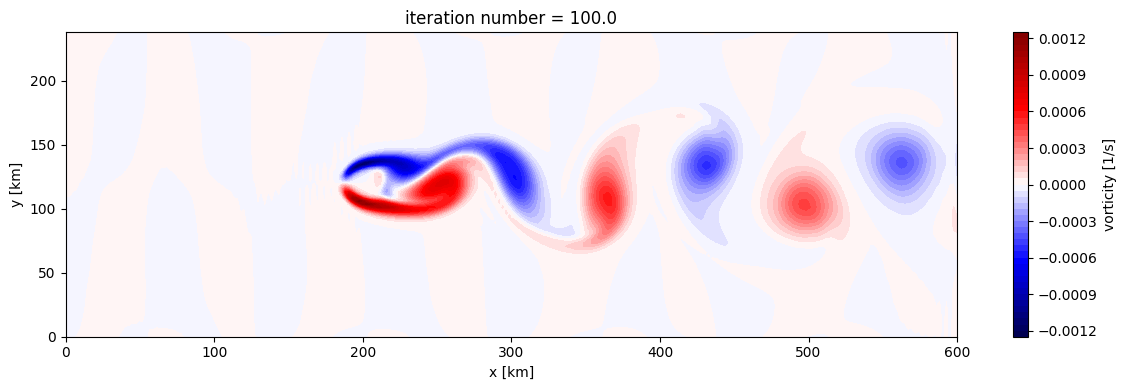

50500


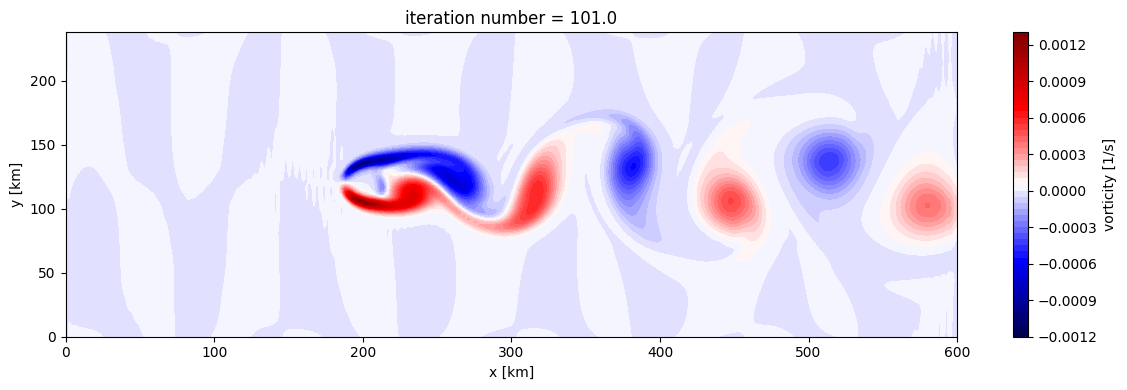

51000


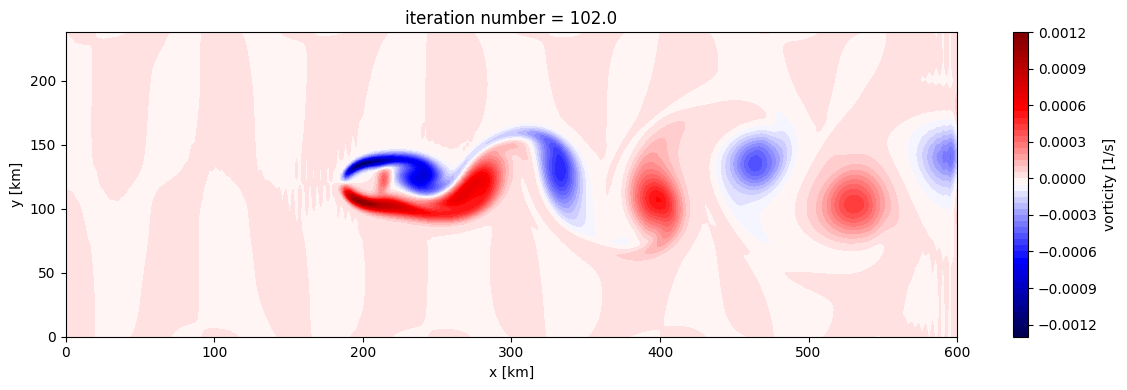

51500


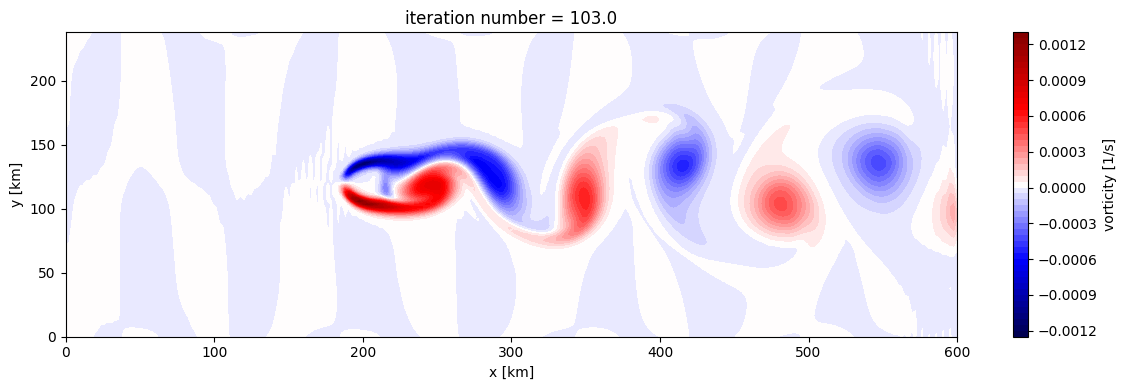

52000


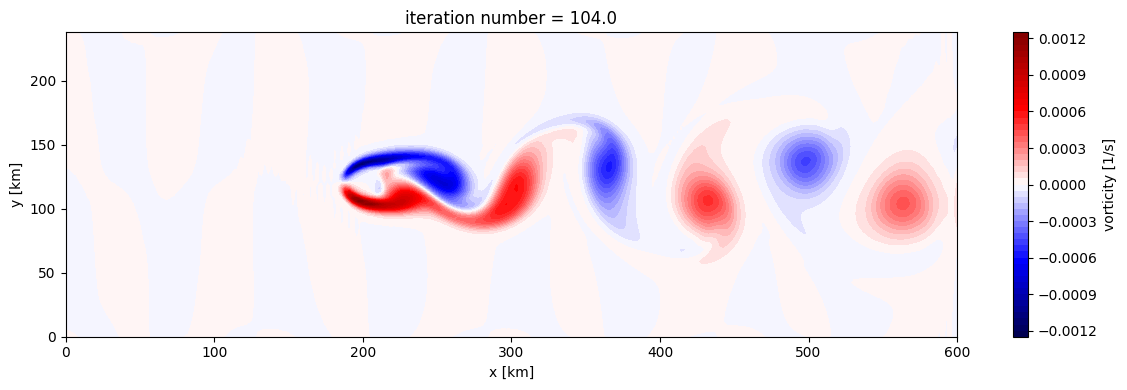

52500


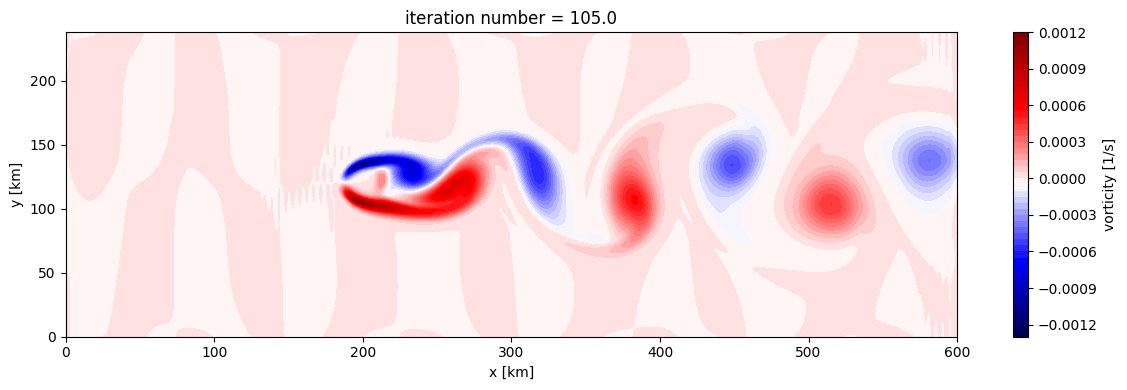

53000


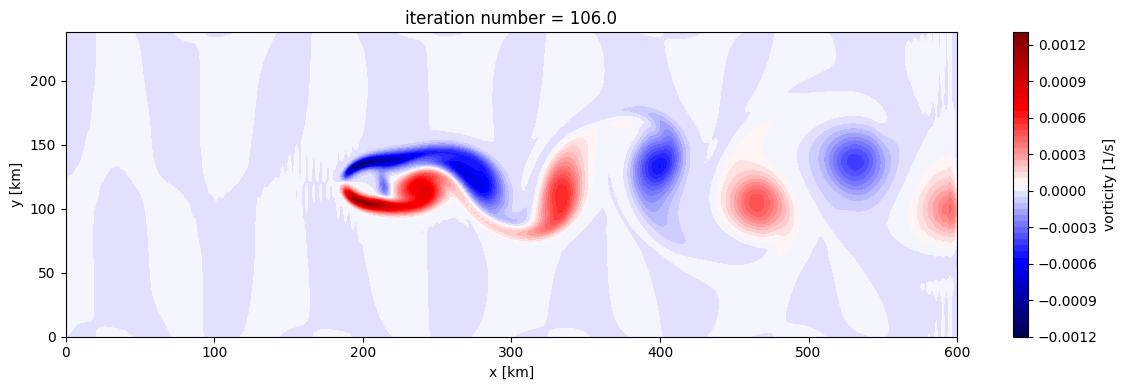

53500


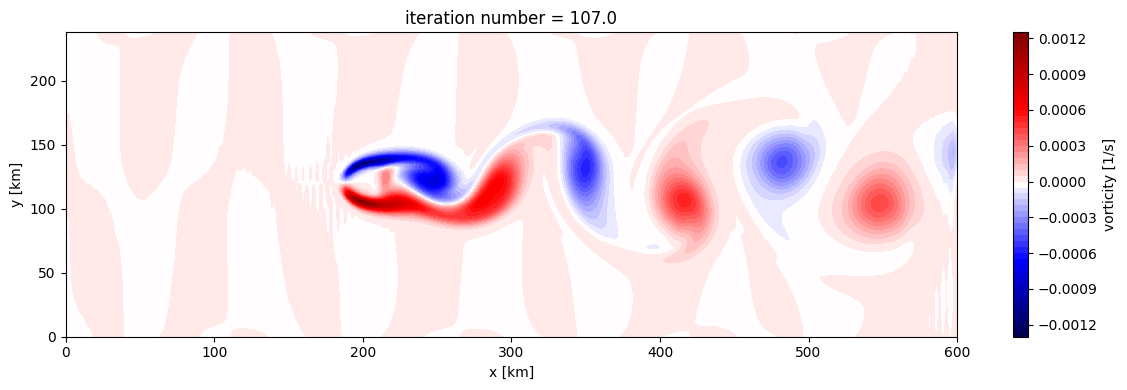

54000


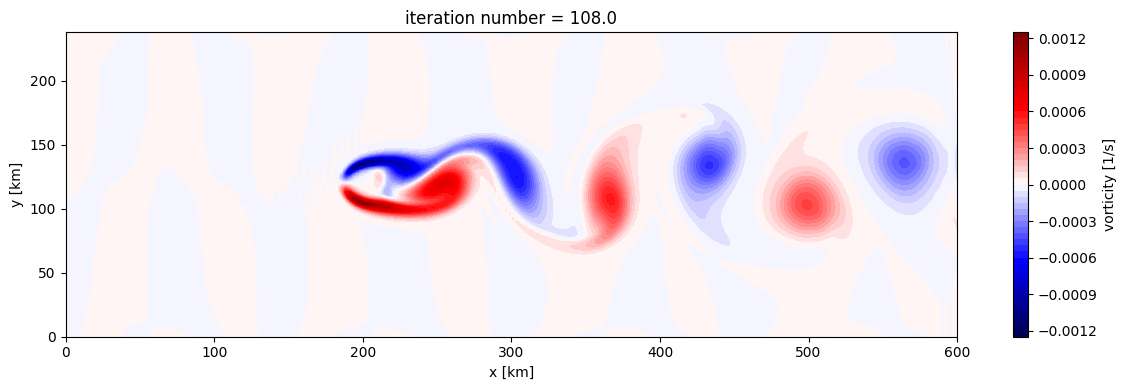

54500


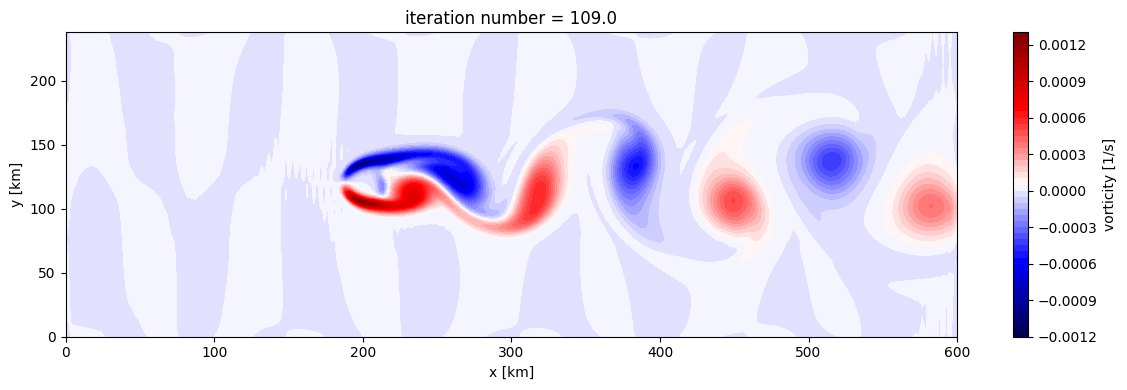

55000


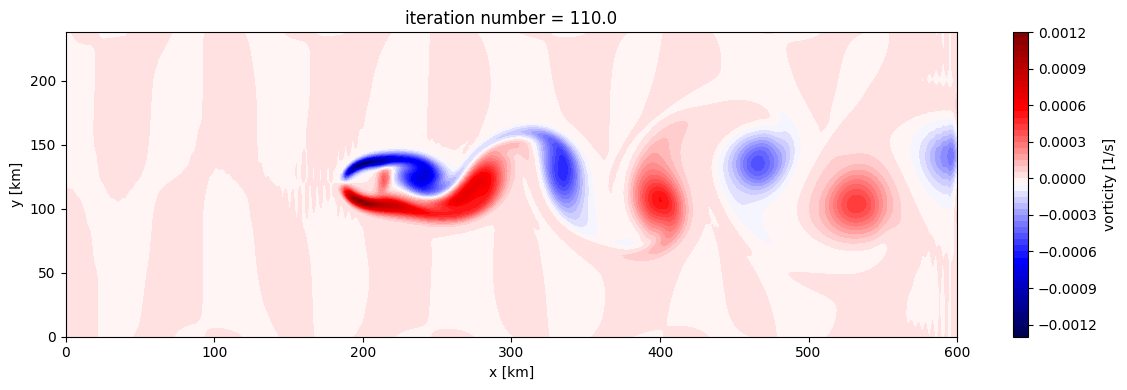

55500


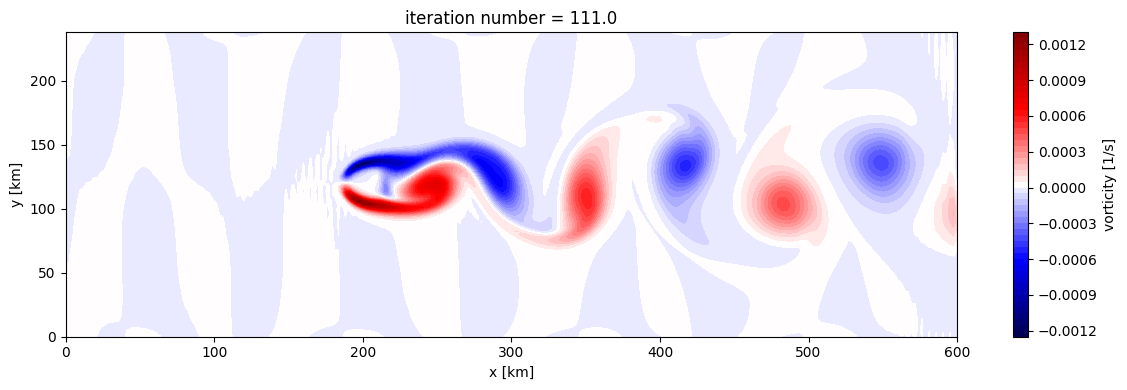

56000


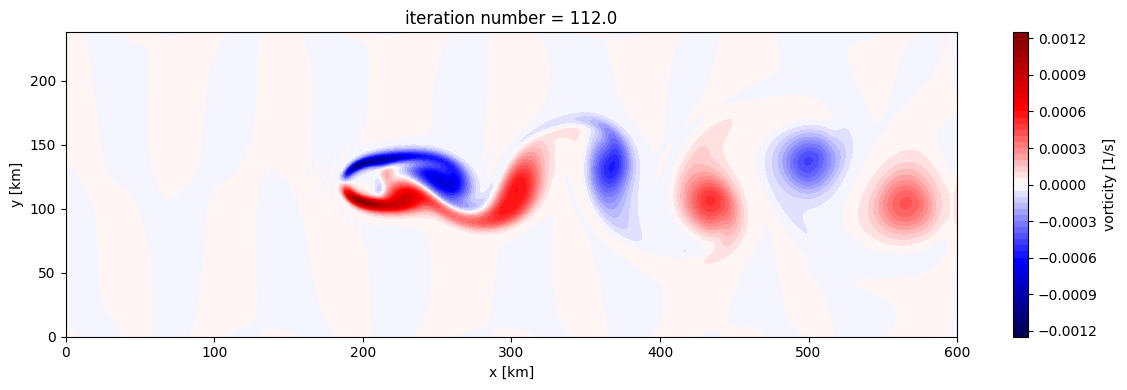

56500


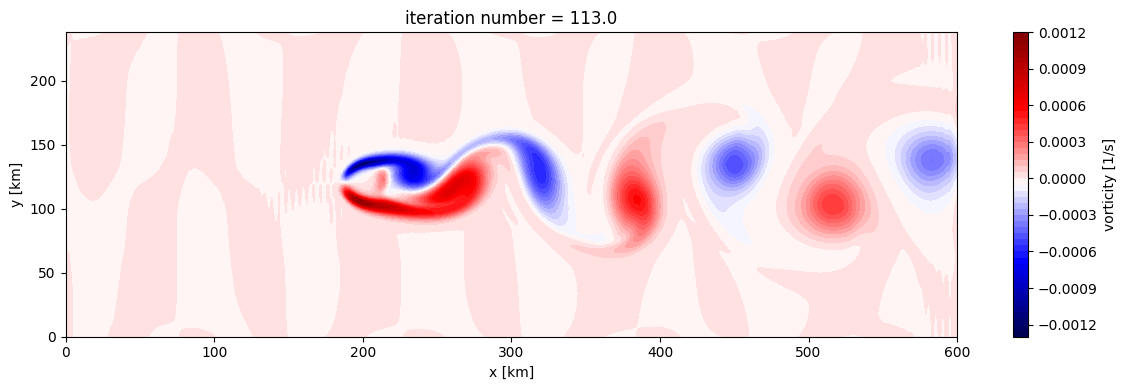

57000


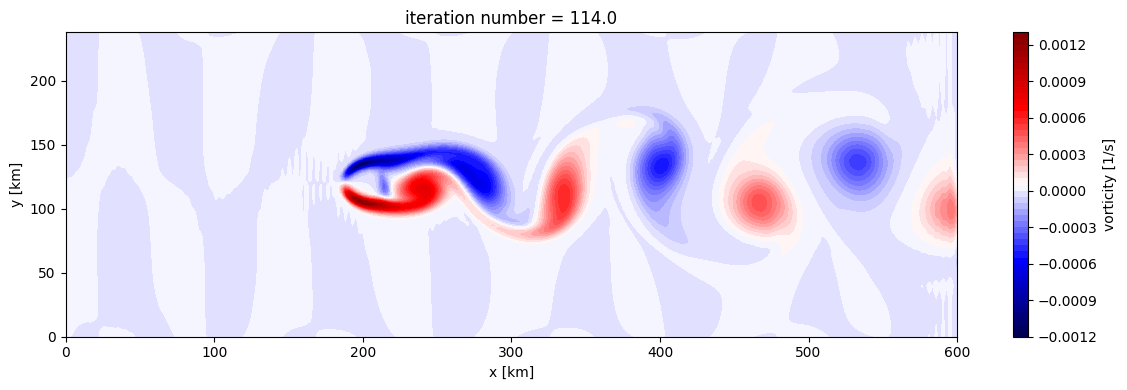

57500


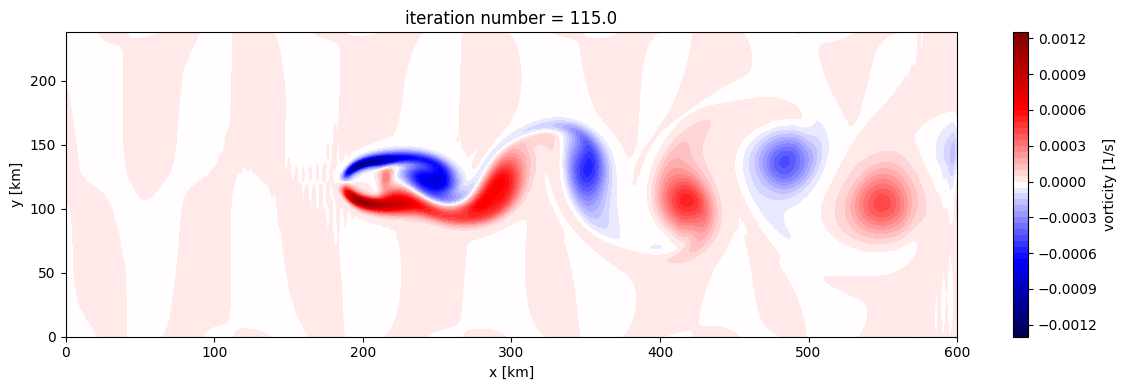

58000


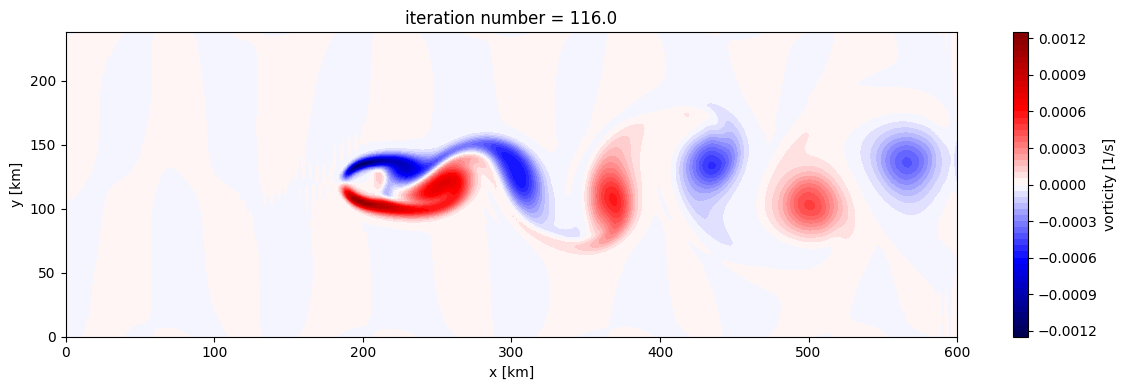

58500


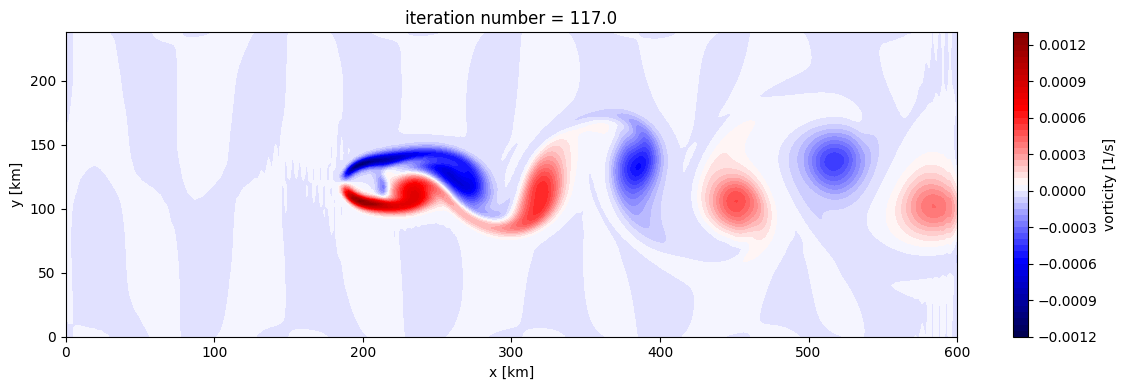

59000


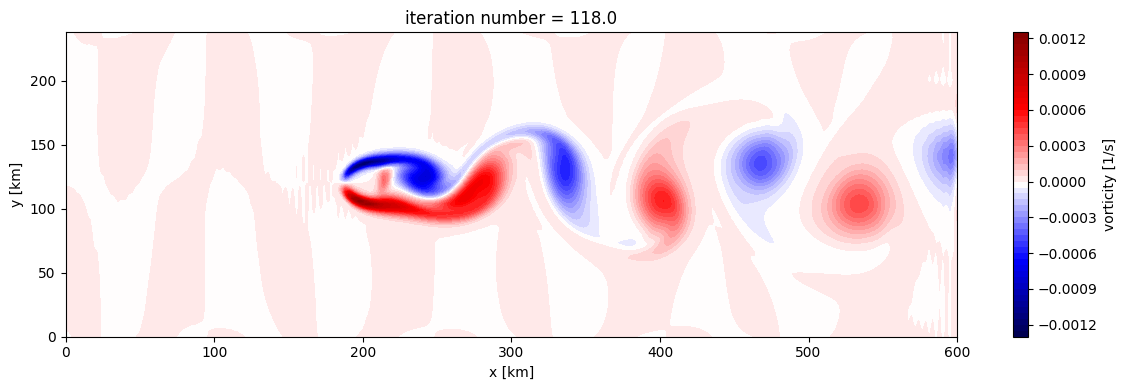

59500


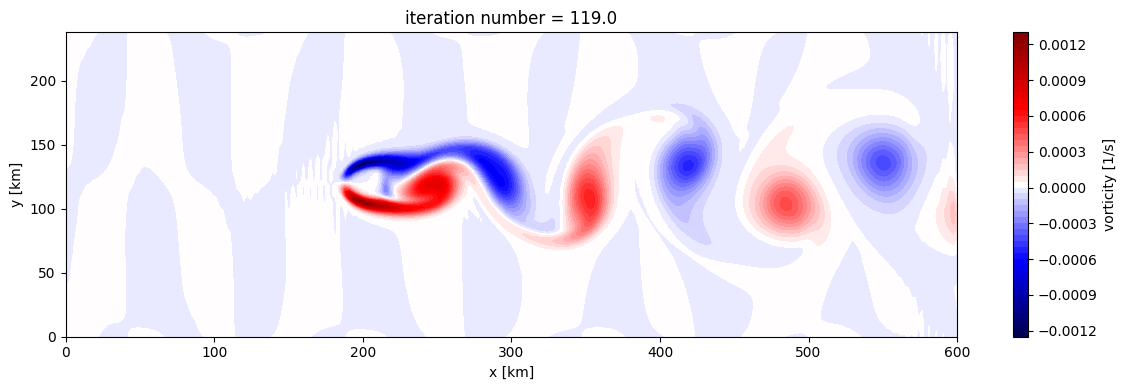

(array([[1000.        , 1427.51325797, 1019.11508088, ..., 1220.07516014,
         1220.86786177, 1220.86786177],
        [1000.        , 1427.38508709, 1019.11423652, ..., 1217.45446197,
         1218.09772916, 1218.09772916],
        [1000.        , 1427.30308462, 1019.11671546, ..., 1214.7894082 ,
         1215.27763531, 1215.27763531],
        ...,
        [1000.        , 1428.16645804, 1019.13359095, ..., 1227.59790757,
         1228.80736819, 1228.80736819],
        [1000.        , 1427.90516925, 1019.12541035, ..., 1225.15390483,
         1226.22945887, 1226.22945887],
        [1000.        , 1427.68672016, 1019.11902329, ..., 1222.64407958,
         1223.58079511, 1223.58079511]], shape=(102, 256)),
 array([[8.        , 5.17222958, 7.22103415, ..., 6.62641547, 6.627811  ,
         6.627811  ],
        [8.        , 5.17313896, 7.22114381, ..., 6.67031053, 6.67156464,
         6.67156464],
        [8.        , 5.17347457, 7.22117615, ..., 6.7139963 , 6.71510242,
         6.715102

In [7]:
update_rk2(h,u,v)


In [8]:
import matplotlib.animation as animation

# same loop but save frames instead of showing plots
def update_rk2_anim(h, u, v, steps=60000):
    zeta_frames = []

    for n in range(steps):
        h, u, v = rk2_step(h, u, v)
        h, u, v = boundary_conditions(h, u, v)

        if n % 100 == 0:
            zeta = ddx(v) - ddy(u)
            zeta_frames.append(zeta.copy())
            

    return h, u, v, zeta_frames


In [9]:
# reset fields to initial state
rng2 = np.random.default_rng(0)
h = np.full((Ny, Nx), H0)
u = np.full((Ny, Nx), U0) + 1*1e-3*U0 * rng2.standard_normal((Ny, Nx))
v = np.zeros((Ny, Nx)) + 1*1e-3*U0 * rng2.standard_normal((Ny, Nx))

# run simulation and collect frames
h, u, v, zeta_frames = update_rk2_anim(h, u, v)
print("done! frames collected:", len(zeta_frames))


done! frames collected: 600


saved vorticity_animation.gif


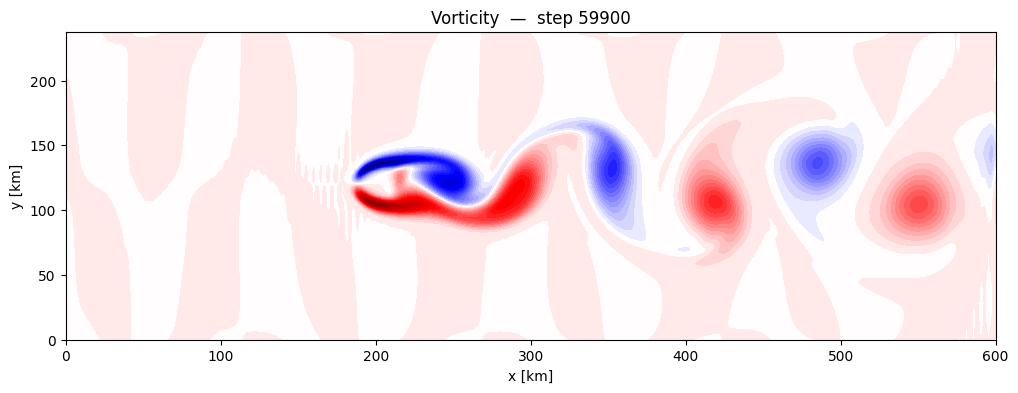

In [10]:
# build animation from saved frames
fig, ax = plt.subplots(figsize=(12, 4))

def draw_frame(i):
    ax.clear()
    ax.contourf(X/1e3, Y/1e3, zeta_frames[i], levels=50, cmap='seismic')
    ax.set_title(f"Vorticity  —  step {i * 100}")
    ax.set_xlabel('x [km]')
    ax.set_ylabel('y [km]')

anim = animation.FuncAnimation(fig, draw_frame, frames=len(zeta_frames), interval=150)

# save as gif 
anim.save('vorticity_animation.gif', writer='pillow', dpi=100)
anim.save('vorticity_animation.mp4', writer='ffmpeg', fps=24, dpi=120)
print("saved vorticity_animation.gif")
plt.show()
